# Step 4 - Visualization #

In [25]:
!pip install imageio

In [1]:
# Live Visualizer
import open3d as o3d

def visualize_vignette(geometry_list):
    """
    A helper function to render a list of geometries in Open3D.
    (UPDATED to correctly handle OrientedBoundingBox objects)
    """
    geometries_to_draw = []
    for item in geometry_list:
        geom_type = item.get("type")
        data = item.get("data")

        if geom_type == "points":
            if "color" in item:
                data.paint_uniform_color(item["color"])
            geometries_to_draw.append(data)

        elif geom_type == "mesh":
            material = item.get("material", {})
            color = material.get("color", [0.8, 0.8, 0.8])
            data.paint_uniform_color(color)
            geometries_to_draw.append(data)

        elif geom_type == "lines":
            if "color" in item:
                # Check if the object is an OrientedBoundingBox
                if isinstance(data, o3d.geometry.OrientedBoundingBox):
                    # OBBs use the .color property instead of a method
                    data.color = item["color"]
                else:
                    # For regular LineSets, use the original method
                    data.paint_uniform_color(item["color"])
            geometries_to_draw.append(data)

    o3d.visualization.draw_geometries(geometries_to_draw)

In [27]:
import open3d as o3d
import json

def save_view_point(geometry_list, output_json_path):
    """
    Opens an interactive Open3D window and saves the camera's extrinsic
    matrix to a file when the 'S' key is pressed.
    """
    # Use the same logic from your visualize_vignette to prepare geometries
    geometries_to_draw = []
    # ... (omitting the geometry prep loop from your function for brevity,
    # but it would be the same as in visualize_vignette) ...
    for item in geometry_list:
        # This part is simplified, assuming data is ready to be drawn
        geometries_to_draw.append(item.get("data"))

    print(f"Position the camera, then press 'S' to save the viewpoint to '{output_json_path}'.")
    
    # Use the Visualizer with key callbacks
    vis = o3d.visualization.VisualizerWithKeyCallback()
    vis.create_window()
    for geom in geometries_to_draw:
        vis.add_geometry(geom)

    def save_callback(vis):
        params = vis.get_view_control().convert_to_pinhole_camera_parameters()
        with open(output_json_path, 'w') as f:
            json.dump(params.extrinsic, f, indent=4, cls=np.ndarray_encoder)
        print(f"Saved camera extrinsic matrix to {output_json_path}")

    vis.register_key_callback(ord("S"), save_callback)
    vis.run()
    vis.destroy_window()

# Custom encoder for saving numpy arrays to JSON
class np_ndarray_encoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return json.JSONEncoder.default(self, obj)

In [33]:
import open3d as o3d
import numpy as np
import imageio
from typing import List

def visualize_vignette_animated(
    geometry_list: List[dict],
    start_position: np.ndarray = [1.5, 0.5, 1.5],
    end_position: np.ndarray = [-1.5, 0.5, 1.5],
    output_gif_path: str = "animation.gif",
    duration_seconds: int = 5,
    fps: int = 30,
    look_at_target: np.ndarray = np.array([0., 0., 0.]),
    up_vector: np.ndarray = np.array([0., 1., 0.])
):
    """
    Renders an animated GIF by moving the camera from a start to an end position,
    always looking at a specified target.

    Args:
        geometry_list: The list of geometries to draw, in your standard format.
        start_position: A numpy array for the camera's starting (x, y, z) position.
        end_position: A numpy array for the camera's ending (x, y, z) position.
        output_gif_path: The file path to save the final GIF.
        duration_seconds: The duration of the animation.
        fps: Frames per second for the output GIF.
        look_at_target: The 3D point the camera will always face.
        up_vector: The "up" direction for the camera.
    """
    # --- 1. Prepare geometries (same logic as before) ---
    geometries_to_draw = []
    for item in geometry_list:
        geom_type = item.get("type")
        data = item.get("data")
        # (This logic is the same as your visualize_vignette helper)
        if geom_type == "points":
            if "color" in item: data.paint_uniform_color(item["color"])
        elif geom_type == "mesh":
            material = item.get("material", {}); color = material.get("color", [0.8, 0.8, 0.8])
            data.paint_uniform_color(color)
        elif geom_type == "lines":
            if "color" in item:
                if isinstance(data, o3d.geometry.OrientedBoundingBox): data.color = item["color"]
                else: data.paint_uniform_color(item["color"])
        geometries_to_draw.append(data)
    
    # --- 2. Setup the non-blocking visualizer ---
    vis = o3d.visualization.Visualizer()
    vis.create_window(visible=False) # Use visible=False for off-screen rendering
    for geom in geometries_to_draw:
        vis.add_geometry(geom)

    # --- 3. Rendering loop ---
    num_frames = duration_seconds * fps
    images = []
    print(f"Rendering {num_frames} frames for a {duration_seconds}s GIF...")
    
    for i in range(num_frames):
        t = i / (num_frames - 1) # Interpolation factor from 0.0 to 1.0

        # a) Interpolate the camera's eye position (Linear Interpolation - LERP)
        eye = (1 - t) * start_position + t * end_position
        
        # b) Calculate the "look at" view matrix (camera's extrinsic)
        # This is the core math to make the camera always face the target.
        forward = eye - look_at_target
        forward /= np.linalg.norm(forward)
        right = np.cross(up_vector, forward)
        right /= np.linalg.norm(right)
        new_up = np.cross(forward, right)

        cam_to_world = np.identity(4)
        cam_to_world[:3, 0] = right
        cam_to_world[:3, 1] = new_up
        cam_to_world[:3, 2] = forward
        cam_to_world[:3, 3] = eye
        
        # The extrinsic matrix is the inverse of the camera's pose in the world.
        extrinsic = np.linalg.inv(cam_to_world)

        # c) Update the camera and capture the image
        ctr = vis.get_view_control()
        params = ctr.convert_to_pinhole_camera_parameters()
        params.extrinsic = extrinsic
        ctr.convert_from_pinhole_camera_parameters(params, allow_arbitrary=True) # allow_arbitrary is important here
        
        img = vis.capture_screen_image(do_render=True)
        images.append(np.asarray(img))

    vis.destroy_window()

    # --- 4. Save the collected images as a GIF ---
    print(f"Saving GIF to {output_gif_path}...")
    imageio.mimsave(output_gif_path, images, fps=fps)
    print("Done.")

In [28]:
import open3d as o3d
import numpy as np
import imageio
from typing import List

def visualize_vignette_orbiting(
    geometry_list: List[dict],
    output_gif_path: str = "orbit_animation.gif",
    distance: float = 1.5,
    height: float = 0.5,
    duration_seconds: int = 5,
    fps: int = 30,
    look_at_target: np.ndarray = np.array([0., 0., 0.]),
    up_vector: np.ndarray = np.array([0., 1., 0.])
):
    geometries_to_draw = []
    for item in geometry_list:
        geom_type, data = item.get("type"), item.get("data")
        if geom_type == "points":
            if "color" in item: data.paint_uniform_color(item["color"])
        elif geom_type == "mesh":
            color = item.get("material", {}).get("color", [0.8, 0.8, 0.8])
            data.paint_uniform_color(color)
        elif geom_type == "lines":
            if "color" in item:
                if isinstance(data, o3d.geometry.OrientedBoundingBox):
                    data.color = item["color"]
                else:
                    data.paint_uniform_color(item["color"])
        geometries_to_draw.append(data)

    vis = o3d.visualization.Visualizer()
    vis.create_window(visible=False, width=800, height=600)
    for g in geometries_to_draw:
        vis.add_geometry(g)

    # Debug: use gray background so “all-white” frames are obvious
    #ro = vis.get_render_option()
    #ro.background_color = np.array([0.9, 0.9, 0.9])

    # Get controller once
    ctr = vis.get_view_control()

    num_frames = duration_seconds * fps
    images = []

    for i in range(num_frames):
        t = i / num_frames
        ang = 2.0 * np.pi * t

        eye = np.array([distance * np.cos(ang), height, distance * np.sin(ang)])
        front = (look_at_target - eye)
        front = front / np.linalg.norm(front)
        up = up_vector / np.linalg.norm(up_vector)

        # Update camera via view control (Open3D expects front to be the camera's forward dir)
        ctr.set_lookat(look_at_target.tolist())
        ctr.set_front(front.tolist())   # where camera looks (camera +Z points along -front internally)
        ctr.set_up(up.tolist())
        # Optional: adjust zoom if needed
        # ctr.set_zoom(0.8)

        # Critical: ensure renderer actually draws before capture
        vis.poll_events()
        vis.update_renderer()

        img_float = vis.capture_screen_float_buffer(do_render=True)  # do_render triggers a draw, but we still call update_renderer above
        img_uint8 = (np.asarray(img_float) * 255).astype(np.uint8)
        images.append(img_uint8)

    vis.destroy_window()
    imageio.mimsave(output_gif_path, images, fps=fps)

In [ ]:
# Old version
import open3d as o3d
import numpy as np
import imageio
from typing import List

def visualize_vignette_orbiting(
    geometry_list: List[dict],
    output_gif_path: str = "orbit_animation.gif",
    distance: float = 1.5,
    height: float = 0.5,
    duration_seconds: int = 5,
    fps: int = 30,
    look_at_target: np.ndarray = np.array([0., 0., 0.]),
    up_vector: np.ndarray = np.array([0., 1., 0.])
):
    """
    Renders an animated GIF of a camera orbiting the origin in a circle.
    (UPDATED with fully corrected camera matrix calculation)
    """
    # ... (Geometry preparation is the same)
    geometries_to_draw = []
    for item in geometry_list:
        geom_type, data = item.get("type"), item.get("data")
        if geom_type == "points":
            if "color" in item: data.paint_uniform_color(item["color"])
        elif geom_type == "mesh":
            material = item.get("material", {}); color = material.get("color", [0.8, 0.8, 0.8])
            data.paint_uniform_color(color)
        elif geom_type == "lines":
            if "color" in item:
                if isinstance(data, o3d.geometry.OrientedBoundingBox): data.color = item["color"]
                else: data.paint_uniform_color(item["color"])
        geometries_to_draw.append(data)

    vis = o3d.visualization.Visualizer()
    vis.create_window(visible=False, width=800, height=600)
    for geom in geometries_to_draw:
        vis.add_geometry(geom)

    num_frames = duration_seconds * fps
    images = []
    print(f"Rendering {num_frames} frames for a {duration_seconds}s orbit...")
    
    for i in range(num_frames):
        t = i / num_frames
        angle = t * 2 * np.pi
        
        eye = np.array([distance * np.cos(angle), height, distance * np.sin(angle)])
        
        # --- [THE FIX] Replaced the entire camera matrix calculation ---
        # This is the standard "look at" matrix calculation, which directly
        # builds the world-to-camera (extrinsic) matrix.
        
        # 1. Calculate camera's local axes (z, x, y)
        z_axis = eye - look_at_target
        z_axis /= np.linalg.norm(z_axis)
        
        x_axis = np.cross(up_vector, z_axis)
        x_axis /= np.linalg.norm(x_axis)
        
        y_axis = np.cross(z_axis, x_axis)

        # 2. Construct the 4x4 extrinsic matrix
        extrinsic = np.identity(4)
        extrinsic[0, :3] = x_axis
        extrinsic[1, :3] = y_axis
        extrinsic[2, :3] = z_axis
        extrinsic[:3, 3] = -np.dot(extrinsic[:3,:3], eye)
        # --- END OF FIX ---

        ctr = vis.get_view_control()
        params = ctr.convert_to_pinhole_camera_parameters()
        params.extrinsic = extrinsic
        ctr.convert_from_pinhole_camera_parameters(params, allow_arbitrary=True)
        
        img_float = vis.capture_screen_float_buffer(do_render=True)
        img_uint8 = (np.asarray(img_float) * 255).astype(np.uint8)
        images.append(img_uint8)

    vis.destroy_window()

    print(f"Saving GIF to {output_gif_path}...")
    imageio.mimsave(output_gif_path, images, fps=fps)
    print("Done.")

In [2]:
from pathlib import Path
import sys
from pipeline import abstraction
import open3d as o3d
import matplotlib.pyplot as plt

project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

VIGNETTE_NAME = "arch"
VIGNETTE_PATH = project_root / "test_data" / VIGNETTE_NAME
results_path = VIGNETTE_PATH / "results"
out_path = VIGNETTE_PATH / "animation"
out_path.mkdir(parents=True, exist_ok=True)

# Load vignette
processed_vignette_path = results_path / "processed_vignette.npz"
from pipeline.vignette_data import ProcessedVignette
processed_vignette = ProcessedVignette.load(processed_vignette_path)

Set/updated per-point attribute: 'uv_coords'.
Set/updated per-point attribute: 'confidence'.
Set/updated per-point attribute: 'component_id'.
Set/updated per-point attribute: 'curvature'.
Set/updated per-point attribute: 'edgeness'.
Set/updated per-point attribute: 'anisotropy'.
Set/updated per-point attribute: 'planarity'.
Set/updated per-point attribute: 'sphericity'.
Set/updated per-point attribute: 'flow_vectors'.
Set/updated per-point attribute: '2d_edges'.
Set/updated per-point attribute: '2d_texture_detail'.
Set/updated per-point attribute: 'stylized_colors'.
Set/updated per-point attribute: 'plane_id'.
Loaded processed vignette from: /Users/yuzhenzhang/Documents/Research/TestApp/SpatialVignetteServer/test_data/arch/results/processed_vignette.npz


## Point Wise Attributes ##

### The Flow Curves ###

In [3]:
# See flow as vectors

import open3d as o3d
import numpy as np


def generate_flow_lines(
    vignette: 'ProcessedVignette',
    density: float = 0.3,
    line_length_multiplier: float = 0.05
) -> o3d.geometry.LineSet:
    """
    Generates a LineSet visualizing the 'flow' across the object's surface.

    Args:
        vignette: The vignette, with 'flow_vectors' attribute calculated.
        density: The fraction of points to draw a flow line for (0.0 to 1.0).
        line_length_multiplier: A scalar to control the length of the flow lines.

    Returns:
        An Open3D LineSet object showing the flow vectors.
    """
    if vignette.get_attribute('flow_vectors') is None:
        raise ValueError("'flow_vectors' attribute not found. Please run analysis first.")

    num_points_to_sample = int(vignette.n_points * density)
    if num_points_to_sample == 0:
        return o3d.geometry.LineSet()

    # 1. Randomly sample a subset of points to avoid clutter
    sampled_indices = np.random.choice(vignette.n_points, num_points_to_sample, replace=False)

    start_points = vignette.points[sampled_indices]
    vectors = vignette.flow_vectors[sampled_indices]

    # 2. Calculate the end points of the lines
    end_points = start_points + vectors * line_length_multiplier

    # 3. Combine start and end points into a single list for the LineSet
    all_points = np.vstack((start_points, end_points))

    # 4. Create the line connections
    lines = [[i, i + num_points_to_sample] for i in range(num_points_to_sample)]

    # 5. Create the LineSet geometry
    line_set = o3d.geometry.LineSet()
    line_set.points = o3d.utility.Vector3dVector(all_points)
    line_set.lines = o3d.utility.Vector2iVector(lines)

    return line_set


def visualize_flow_field(
    vignette: 'ProcessedVignette',
    density: float = 0.8,
    length: float = 0.04,
    color: list = [0.2, 0.4, 1.0]
):
    """
    Generates and visualizes the flow vectors in space without the base point cloud.

    Args:
        vignette: The processed vignette object.
        density: The fraction of points to visualize (0.0 to 1.0).
        length: The length of the rendered vector lines.
        color: The color to use for the lines.
    """
    print("🌊 Visualizing abstract flow field...")
    
    # 1. Generate the flow line geometry
    flow_field_lines = generate_flow_lines(
        vignette=vignette,
        density=density,
        line_length_multiplier=length
    )
    
    # 2. Call your visualization helper with only the lines
    visualize_vignette([
        {
            "type": "lines",
            "data": flow_field_lines,
            "color": color
        }
    ])
    print("Done.")

# --- Example Usage ---
visualize_flow_field(processed_vignette, density=0.5, length=0.02, color=[0.2, 0.1, 0.7])

🌊 Visualizing abstract flow field...
Done.


In [4]:
# Show flow at areas

import open3d as o3d
import numpy as np


def visualize_dominant_flow(
    vignette: 'ProcessedVignette',
    filter_attribute: str,
    threshold: float,
    direction: str = "above",
    length: float = 0.04,
    color: list = [1.0, 0.5, 0.0]  # Default to an impactful orange
):
    """
    Generates and visualizes flow vectors only for points that pass a filter
    based on another attribute, highlighting the "main" flow directions.

    Args:
        vignette: The processed vignette object.
        filter_attribute: The attribute to use for filtering (e.g., 'edgeness', 'curvature').
        threshold: The cutoff value for the filter attribute.
        direction: How to filter: 'above' (default) or 'below' the threshold.
        length: The visual length of the rendered flow lines.
        color: The color to use for the lines.
    """
    print(f"🔎 Visualizing dominant flow where '{filter_attribute}' is {direction} {threshold}...")

    # --- 1. Input Validation ---
    if vignette.get_attribute('flow_vectors') is None:
        raise ValueError("'flow_vectors' attribute not found. Please run analysis first.")
    
    attr_values = vignette.get_attribute(filter_attribute)
    if attr_values is None:
        raise ValueError(f"Filter attribute '{filter_attribute}' not found in vignette.")

    # --- 2. Filter the points ---
    if direction == "above":
        mask = attr_values >= threshold
    elif direction == "below":
        mask = attr_values <= threshold
    else:
        raise ValueError("Direction must be 'above' or 'below'.")

    dominant_indices = np.where(mask)[0]

    if len(dominant_indices) == 0:
        print("Warning: No points passed the filter with the given settings.")
        return

    print(f"   - Found {len(dominant_indices)} points that match the criterion.")

    # --- 3. Generate LineSet from filtered points ---
    start_points = vignette.points[dominant_indices]
    vectors = vignette.flow_vectors[dominant_indices]
    end_points = start_points + vectors * length

    all_points = np.vstack((start_points, end_points))
    num_lines = len(start_points)
    lines = [[i, i + num_lines] for i in range(num_lines)]

    dominant_flow_lines = o3d.geometry.LineSet()
    dominant_flow_lines.points = o3d.utility.Vector3dVector(all_points)
    dominant_flow_lines.lines = o3d.utility.Vector2iVector(lines)
    
    # --- 4. Visualize the result ---
    visualize_vignette([
        {
            "type": "lines",
            "data": dominant_flow_lines,
            "color": color
        }
    ])
    print("Done.")

In [23]:
# Idea 1: Show the flow along the sharpest edges.
# This reveals how the primary forms of the object direct movement along its creases.
visualize_dominant_flow(
    processed_vignette,
    filter_attribute='edgeness',
    threshold=0.7,
    length=0.05,
    color=[0.2, 0.1, 0.7] # Red for edges
)

🔎 Visualizing dominant flow where 'edgeness' is above 0.7...
   - Found 1733 points that match the criterion.
Done.


In [32]:
# **Idea 2: Show the flow across the flattest surfaces.**
# This is great for understanding the grain or direction of planar regions.
visualize_dominant_flow(
    processed_vignette,
    filter_attribute='planarity',
    threshold=0.8,
    direction="above",
    length=0.03,
    color=[0.2, 0.1, 0.7]
)

🔎 Visualizing dominant flow where 'planarity' is above 0.8...
   - Found 19878 points that match the criterion.
Done.


In [6]:
# **Idea 3: Show the flow around the most curved areas.**
# This highlights movement around spherical or cylindrical parts.
visualize_dominant_flow(
    processed_vignette,
    filter_attribute='curvature',
    threshold=0.02,
    direction="above",
    length=0.06,
    color=[0.2, 0.1, 0.7]
)

🔎 Visualizing dominant flow where 'curvature' is above 0.02...
   - Found 33 points that match the criterion.
Done.


In [6]:
# Iso curves test
import open3d as o3d
import numpy as np

def visualize_flow_isocurves(
    vignette: 'ProcessedVignette',
    num_curves: int = 50,
    max_steps: int = 100,
    step_size: float = 0.01,
    curvature_influence: float = 2.0
):
    """
    Generates and visualizes iso-curves that follow the flow field,
    with density weighted by local curvature.

    Args:
        vignette: The processed vignette with local features calculated.
        num_curves: The total number of curves to generate.
        max_steps: The maximum number of points in a single curve.
        step_size: The distance to travel in the direction of the flow vector at each step.
        curvature_influence: A power to raise curvature values to, increasing the
                             probability of seeding in high-curvature zones.
    """
    print("〰️ Generating flow iso-curves...")

    # --- 1. Setup for efficient searching ---
    pcd = vignette.to_open3d()
    pcd_tree = o3d.geometry.KDTreeFlann(pcd)

    # --- 2. Curvature-Weighted Seeding ---
    curvatures = vignette.get_attribute('curvature')
    if curvatures is None:
        raise ValueError("Attribute 'curvature' not found. Please run analysis first.")

    # Normalize curvature and apply influence factor to create probabilities
    probs = (curvatures - curvatures.min()) / (curvatures.max() - curvatures.min())
    probs = np.power(probs, curvature_influence)
    probs /= probs.sum() # Ensure probabilities sum to 1

    # Select starting points based on the calculated probabilities
    seed_indices = np.random.choice(vignette.n_points, size=num_curves, p=probs, replace=False)

    # --- 3. Trace each streamline ---
    all_lines = []
    points = vignette.points
    flow_vectors = vignette.flow_vectors

    for start_idx in seed_indices:
        # Trace in the forward direction
        forward_curve = [start_idx]
        current_idx = start_idx
        for _ in range(max_steps // 2):
            # Get the current position and flow direction
            pos = points[current_idx]
            direction = flow_vectors[current_idx]

            # Find the nearest point on the surface after taking a step
            [k, idx, _] = pcd_tree.search_knn_vector_3d(pos + direction * step_size, 1)
            next_idx = idx[0]

            if next_idx in forward_curve: break # Stop if we loop back
            forward_curve.append(next_idx)
            current_idx = next_idx

        # Trace in the backward direction
        backward_curve = []
        current_idx = start_idx
        for _ in range(max_steps // 2):
            pos = points[current_idx]
            direction = flow_vectors[current_idx] # Move against the flow

            [k, idx, _] = pcd_tree.search_knn_vector_3d(pos - direction * step_size, 1)
            next_idx = idx[0]

            if next_idx in forward_curve or next_idx in backward_curve: break
            backward_curve.append(next_idx)
            current_idx = next_idx
        
        # Combine into a single curve and create line segments
        full_curve = backward_curve[::-1] + forward_curve
        if len(full_curve) > 1:
            for i in range(len(full_curve) - 1):
                all_lines.append([full_curve[i], full_curve[i+1]])

    # --- 4. Create LineSet and Visualize ---
    if not all_lines:
        print("Warning: No curves were generated.")
        return

    isocurve_lineset = o3d.geometry.LineSet()
    isocurve_lineset.points = o3d.utility.Vector3dVector(points)
    isocurve_lineset.lines = o3d.utility.Vector2iVector(all_lines)
    
    print(f"   - Generated {len(all_lines)} line segments from {num_curves} seeds.")

    # Visualize the curves on top of a subtle, gray version of the point cloud
    visualize_vignette([
        #{"type": "points", "data": vignette.to_open3d('rgb'), "color": [0.8, 0.8, 0.8]},
        {"type": "lines", "data": isocurve_lineset, "color": [0.2, 0.1, 0.7]}
    ])
    print("Done.")

# --- Example Usage ---
# Assuming 'processed_vignette' is loaded and analyzed:

visualize_flow_isocurves(
    processed_vignette,
    num_curves=5,
    max_steps=200,
    step_size=0.04, # Smaller step size gives smoother curves
    curvature_influence=3.0 # Higher value concentrates curves even more
)

〰️ Generating flow iso-curves...
Generating Open3D point cloud with 'rgb' colors...
   - Generated 108 line segments from 5 seeds.
Done.


### Glyph-Like Spheres ###

In [5]:
# Just visualize filtered values
import open3d as o3d
import numpy as np

def visualize_filtered_attribute(
    vignette: 'ProcessedVignette',
    attribute: str,
    threshold: float,
    direction: str = "above",
    show_context: bool = True
):
    """
    Isolates and visualizes points that meet a specific attribute criterion.

    Args:
        vignette: The processed vignette.
        attribute: The attribute to filter by (e.g., 'edgeness').
        threshold: The cutoff value for the filter.
        direction: How to filter: 'above' (default) or 'below'.
        show_context: If True, shows the rest of the point cloud in gray.
    """
    print(f"🔎 Filtering for '{attribute}' {direction} {threshold}...")

    # Use the existing method to get the filtered point cloud
    filtered_pcd = vignette.to_open3d_threshold(
        attr=attribute,
        threshold=threshold,
        direction=direction
    )

    geometries = []
    if show_context:
        # Add the full point cloud as a faint gray background
        context_pcd = vignette.to_open3d('rgb')
        context_pcd.paint_uniform_color([0.7, 0.7, 0.7])
        geometries.append({"type": "points", "data": context_pcd})
    
    # Add the vibrant, filtered points on top
    # The filtered_pcd already has its original RGB colors
    geometries.append({"type": "points", "data": filtered_pcd})

    visualize_vignette(geometries)
    print("Done.")

In [6]:
visualize_filtered_attribute(
    processed_vignette, 
    'edgeness', 
    threshold=0.5, 
    direction="above", 
    show_context=True
)

🔎 Filtering for 'edgeness' above 0.5...
Generating Open3D point cloud with 'rgb' colors...
Done.


In [7]:
import open3d as o3d
import numpy as np
from typing import Optional

def visualize_attribute_as_sized_spheres(
    vignette: 'ProcessedVignette',
    attribute: str,
    density: float = 0.5,
    stride: Optional[int] = None,
    min_scale: float = 0.002,
    max_scale: float = 0.03,
    color: list = [0.9, 0.2, 0.1],
    show_context: bool = True
):
    """
    Visualizes an attribute's magnitude by mapping it to the radius of sphere glyphs.
    Now supports uniform sampling with a 'stride' parameter.
    """
    print(f"✨ Visualizing '{attribute}' magnitude with sized spheres...")

    # --- (Sections 1-3 are unchanged) ---
    attr_values = vignette.get_attribute(attribute)
    if attr_values is None:
        raise ValueError(f"Attribute '{attribute}' not found in the vignette.")

    if stride is not None and stride > 0:
        print(f"   - Using stride sampling: selecting every {stride}th point.")
        sampled_indices = np.arange(vignette.n_points)[::stride]
    else:
        print(f"   - Using random density sampling: selecting {density*100}% of points.")
        num_points_to_sample = int(vignette.n_points * density)
        if num_points_to_sample == 0:
            print("Warning: Density is too low, no points to sample.")
            return
        sampled_indices = np.random.choice(vignette.n_points, num_points_to_sample, replace=False)

    if len(sampled_indices) == 0:
        print("Warning: No points were sampled.")
        return

    min_val, max_val = attr_values.min(), attr_values.max()
    value_range = max_val - min_val if (max_val - min_val) > 1e-6 else 1.0

    # --- 4. Create and Merge Glyphs (Unchanged) ---
    merged_spheres = o3d.geometry.TriangleMesh()
    for i in sampled_indices:
        pos = vignette.points[i]
        val = attr_values[i]
        normalized_val = (val - min_val) / value_range
        radius = min_scale + normalized_val * (max_scale - min_scale)
        glyph = o3d.geometry.TriangleMesh.create_sphere(radius=radius)
        glyph.translate(pos)
        merged_spheres += glyph

    # --- 5. Visualize the Result (CORRECTED) ---
    geometries = []
    if show_context:
        context_pcd = vignette.to_open3d('rgb')
        context_pcd.paint_uniform_color([0.8, 0.8, 0.8])
        geometries.append({"type": "points", "data": context_pcd})
        
    # ** THE FIX IS HERE **
    # We now pass the color inside the 'material' dictionary,
    # which the helper function is designed to read.
    geometries.append({
        "type": "mesh",
        "data": merged_spheres,
        "material": {"color": color} # <-- CORRECTED LINE
    })
    
    visualize_vignette(geometries)
    print("Done.")

# **Idea 1: Visualize Curvature Hotspots with a uniform grid.**
# This will create a very regular pattern of spheres.
# A stride of 10 means you'll visualize 1/10th of the total points.
visualize_attribute_as_sized_spheres(
    processed_vignette,
    attribute='curvature',
    stride=10, # Select every 10th point
    min_scale=0.001,
    max_scale=0.01,
    color=[0.2, 0.1, 0.7]
)

✨ Visualizing 'curvature' magnitude with sized spheres...
   - Using stride sampling: selecting every 10th point.
Generating Open3D point cloud with 'rgb' colors...
Done.


In [8]:
import open3d as o3d
import numpy as np

def visualize_attribute_density(
    vignette: 'ProcessedVignette',
    attribute: str,
    power: float = 1.0,
    color_by_attribute: bool = True
):
    """
    Creates a new point cloud whose density is modulated by an attribute's value.

    Args:
        vignette: The processed vignette.
        attribute: The attribute to drive the density (e.g., 'curvature', 'edgeness').
        power: A factor to increase the contrast. >1 makes density gaps more extreme.
        color_by_attribute: If True, colors the final points by the attribute value.
    """
    print(f"👻 Generating density field from '{attribute}'...")

    # --- 1. Get attribute values and normalize them to be probabilities ---
    attr_values = vignette.get_attribute(attribute)
    if attr_values is None:
        raise ValueError(f"Attribute '{attribute}' not found.")
        
    min_val, max_val = attr_values.min(), attr_values.max()
    normalized_values = (attr_values - min_val) / (max_val - min_val)
    
    # The 'power' factor enhances contrast
    keep_probabilities = np.power(normalized_values, power)

    # --- 2. Decide which points to keep ---
    # Generate a random number for each point; keep it if its probability is higher.
    random_rolls = np.random.rand(vignette.n_points)
    keep_mask = keep_probabilities > random_rolls
    
    num_kept = np.sum(keep_mask)
    if num_kept == 0:
        print("Warning: No points were kept. Try decreasing the 'power' factor.")
        return

    # --- 3. Create the new, sparse point cloud ---
    dense_pcd = o3d.geometry.PointCloud()
    dense_pcd.points = o3d.utility.Vector3dVector(vignette.points[keep_mask])
    
    # --- 4. Color and Visualize ---
    if color_by_attribute:
        # Create a temporary vignette just for coloring
        temp_vignette = ProcessedVignette(
            points=vignette.points[keep_mask],
            colors=vignette.colors[keep_mask]
        )
        temp_vignette.set_attribute(attribute, attr_values[keep_mask])
        dense_pcd = temp_vignette.to_open3d(color_mode=attribute)
    else:
        dense_pcd.colors = o3d.utility.Vector3dVector(vignette.colors[keep_mask])
        
    visualize_vignette([{"type": "points", "data": dense_pcd}])
    print(f"   - Kept {num_kept} of {vignette.n_points} points.")

# --- Example Usage ---
visualize_attribute_density(
    processed_vignette,
    attribute='curvature',
    power=1.5, # Higher power = sparser result with more contrast
    color_by_attribute=False
)

👻 Generating density field from 'curvature'...
   - Kept 230 of 3597 points.


In [9]:
import open3d as o3d
import numpy as np

def visualize_artistic_density_field(
    vignette: 'ProcessedVignette',
    attribute: str,
    power: float = 1.0,
    show_context: bool = True,
    show_connection: bool = True,
    num_neighbors_for_web: int = 5,
    point_color: list = [0.2, 0.1, 0.7],
    line_color: list = [0.2, 0.8, 0.8]
):
    """
    Creates an artistic point cloud with attribute-modulated density,
    with options to show context and a connecting web.

    Args:
        vignette: The processed vignette.
        attribute: The attribute to drive the density (e.g., 'curvature').
        power: A factor to increase density contrast. >1 is more extreme.
        show_context: If True, adds the full, original point cloud in gray.
        show_connection: If True, adds a web of lines connecting nearby dense points.
        num_neighbors_for_web: The number of neighbors to connect for each point in the web.
        point_color: The color for the dense points.
        line_color: The color for the connection web.
    """
    print(f"🎨 Generating artistic density field from '{attribute}'...")

    # --- 1. Resample the point cloud based on the attribute (same as before) ---
    attr_values = vignette.get_attribute(attribute)
    if attr_values is None:
        raise ValueError(f"Attribute '{attribute}' not found.")
        
    min_val, max_val = attr_values.min(), attr_values.max()
    normalized_values = (attr_values - min_val) / (max_val - min_val)
    keep_probabilities = np.power(normalized_values, power)
    random_rolls = np.random.rand(vignette.n_points)
    keep_mask = keep_probabilities > random_rolls
    
    num_kept = np.sum(keep_mask)
    if num_kept == 0:
        print("Warning: No points were kept. Try decreasing the 'power' factor.")
        return
        
    # --- 2. Prepare the list of geometries to draw ---
    geometries = []

    # --- 3. (Optional) Add the context point cloud ---
    if show_context:
        context_pcd = vignette.to_open3d('rgb')
        context_pcd.paint_uniform_color([0.85, 0.85, 0.85]) # A light gray
        geometries.append({"type": "points", "data": context_pcd})

    # --- 4. Create the primary (dense) point cloud ---
    dense_points = vignette.points[keep_mask]
    dense_pcd = o3d.geometry.PointCloud()
    dense_pcd.points = o3d.utility.Vector3dVector(dense_points)
    dense_pcd.paint_uniform_color(point_color)
    geometries.append({"type": "points", "data": dense_pcd})

    # --- 5. (Optional) Generate the connection web ---
    if show_connection:
        print("   - Generating connection web...")
        # Build a KD-Tree on ONLY the dense points for efficiency
        pcd_tree = o3d.geometry.KDTreeFlann(dense_pcd)
        lines = []
        
        # For each point in our new dense cloud
        for i in range(len(dense_points)):
            # Find its nearest neighbors *within the dense cloud*
            [k, idx, _] = pcd_tree.search_knn_vector_3d(dense_points[i], num_neighbors_for_web + 1)
            
            # Create lines connecting to its neighbors (excluding itself)
            for neighbor_idx in idx[1:]:
                lines.append([i, neighbor_idx])
        
        web_lineset = o3d.geometry.LineSet()
        web_lineset.points = o3d.utility.Vector3dVector(dense_points)
        web_lineset.lines = o3d.utility.Vector2iVector(lines)
        web_lineset.paint_uniform_color(line_color)
        geometries.append({"type": "lines", "data": web_lineset})

    # --- 6. Visualize the final composition ---
    visualize_vignette(geometries)
    print(f"   - Kept {num_kept} of {vignette.n_points} points for the dense field.")

# --- Example Usage ---
# Assuming 'processed_vignette' is loaded and analyzed.

# **Idea 1: Full visualization - dense points, context, and web**
# visualize_artistic_density_field(
#     processed_vignette,
#     attribute='curvature',
#     power=2.0, # High power for a very sparse, high-contrast result
#     show_context=True,
#     show_connection=True,
#     num_neighbors_for_web=4,
#     point_color=[1.0, 0.4, 0.0], # Orange points
#     line_color=[0.3, 0.3, 0.3]  # Dark gray lines
# )

# **Idea 2: Just the dense points and the web, no context**
# This creates a floating, abstract structure.
visualize_artistic_density_field(
    processed_vignette,
    attribute='curvature',
    power=1.0,
    show_context=False,
    show_connection=True
)

# **Idea 3: Just the dense points with context (same as old function but with color)**
# visualize_artistic_density_field(
#     processed_vignette,
#     attribute='curvature',
#     power=1.0,
#     show_context=True,
#     show_connection=False
# )

🎨 Generating artistic density field from 'curvature'...
   - Generating connection web...
   - Kept 41 of 8948 points for the dense field.


### Filtered Points + Connections ###

In [7]:
import open3d as o3d
import numpy as np

def visualize_artistic_density_field(
    vignette: 'ProcessedVignette',
    attribute: str,
    power: float = 1.0,
    show_context: bool = True,
    show_connection: bool = True,
    show_as_spheres: bool = False, # NEW FLAG
    min_sphere_scale: float = 0.002, # NEW: Sphere scaling control
    max_sphere_scale: float = 0.02,  # NEW: Sphere scaling control
    num_neighbors_for_web: int = 5,
    point_color: list = [1.0, 0.5, 0.0],
    line_color: list = [0.2, 0.2, 0.2]
):
    """
    Creates an artistic point cloud with attribute-modulated density and multiple display options.

    Args:
        vignette: The processed vignette.
        attribute: The attribute to drive the density (e.g., 'curvature').
        power: A factor to increase density contrast. >1 is more extreme.
        show_context: If True, adds the full, original point cloud in gray.
        show_connection: If True, adds a web of lines connecting nearby dense points.
        show_as_spheres: If True, renders the dense points as spheres scaled by the attribute.
        min_sphere_scale: The minimum radius for spheres when show_as_spheres is True.
        max_sphere_scale: The maximum radius for spheres when show_as_spheres is True.
        num_neighbors_for_web: The number of neighbors to connect for each point in the web.
        point_color: The color for the dense points or spheres.
        line_color: The color for the connection web.
    """
    print(f"🎨 Generating artistic density field from '{attribute}'...")

    # --- 1. Resample the point cloud based on the attribute ---
    attr_values = vignette.get_attribute(attribute)
    if attr_values is None:
        raise ValueError(f"Attribute '{attribute}' not found.")
        
    min_val, max_val = attr_values.min(), attr_values.max()
    normalized_values = (attr_values - min_val) / (max_val - min_val)
    keep_probabilities = np.power(normalized_values, power)
    random_rolls = np.random.rand(vignette.n_points)
    keep_mask = keep_probabilities > random_rolls
    
    num_kept = np.sum(keep_mask)
    if num_kept == 0:
        print("Warning: No points were kept. Try decreasing the 'power' factor.")
        return
        
    geometries = []

    # --- 2. (Optional) Add the context point cloud ---
    if show_context:
        context_pcd = vignette.to_open3d('rgb')
        context_pcd.paint_uniform_color([0.85, 0.85, 0.85])
        geometries.append({"type": "points", "data": context_pcd})

    # --- 3. Create the primary (dense) geometry ---
    dense_points = vignette.points[keep_mask]
    
    if show_as_spheres:
        print("   - Representing dense points as scaled spheres...")
        dense_attr_values = attr_values[keep_mask]
        attr_min, attr_max = dense_attr_values.min(), dense_attr_values.max()
        attr_range = attr_max - attr_min if (attr_max - attr_min) > 1e-6 else 1.0

        merged_spheres = o3d.geometry.TriangleMesh()
        for i, pos in enumerate(dense_points):
            val = dense_attr_values[i]
            normalized_val = (val - attr_min) / attr_range
            radius = min_sphere_scale + normalized_val * (max_sphere_scale - min_sphere_scale)
            glyph = o3d.geometry.TriangleMesh.create_sphere(radius=radius)
            glyph.translate(pos)
            merged_spheres += glyph
        
        geometries.append({
            "type": "mesh",
            "data": merged_spheres,
            "material": {"color": point_color}
        })
    else:
        print("   - Representing dense points as a point cloud...")
        dense_pcd = o3d.geometry.PointCloud()
        dense_pcd.points = o3d.utility.Vector3dVector(dense_points)
        dense_pcd.paint_uniform_color(point_color)
        geometries.append({"type": "points", "data": dense_pcd})

    # --- 4. (Optional) Generate the connection web ---
    if show_connection:
        print("   - Generating connection web...")
        temp_pcd_for_kdtree = o3d.geometry.PointCloud()
        temp_pcd_for_kdtree.points = o3d.utility.Vector3dVector(dense_points)
        pcd_tree = o3d.geometry.KDTreeFlann(temp_pcd_for_kdtree)
        lines = []
        
        for i in range(len(dense_points)):
            [k, idx, _] = pcd_tree.search_knn_vector_3d(dense_points[i], num_neighbors_for_web + 1)
            for neighbor_idx in idx[1:]:
                lines.append([i, neighbor_idx])
        
        web_lineset = o3d.geometry.LineSet()
        web_lineset.points = o3d.utility.Vector3dVector(dense_points)
        web_lineset.lines = o3d.utility.Vector2iVector(lines)
        web_lineset.paint_uniform_color(line_color)
        geometries.append({"type": "lines", "data": web_lineset})

    # --- 5. Visualize the final composition ---
    visualize_vignette(geometries)
    print(f"   - Kept {num_kept} of {vignette.n_points} points for the dense field.")

# Show sparse points as scaled spheres, with a connecting web, against a faint context.
# This gives a strong, structural, and beautiful result.
visualize_artistic_density_field(
    processed_vignette,
    attribute='curvature',
    power=1.0, # higher is sparser
    show_context=False,
    show_connection=True,
    show_as_spheres=True,
    min_sphere_scale=0.0003,
    max_sphere_scale=0.003,
    num_neighbors_for_web=4,
    point_color=[0.2, 0.1, 0.7],
    line_color=[0.2, 0.8, 0.8]
)

🎨 Generating artistic density field from 'curvature'...
   - Representing dense points as scaled spheres...
   - Generating connection web...
   - Kept 92 of 44953 points for the dense field.


## 2D Abstractions ##

### Canny Edges ###

In [8]:
# Project code

import numpy as np
import open3d as o3d
from scipy.spatial import KDTree
from typing import List, Tuple, Optional, Dict, Any

def _get_projection_params(vignette: 'ProcessedVignette') -> Dict[str, Any]:
    """Extracts and calculates all necessary projection data from a vignette."""
    try:
        meta = vignette.metadata["capture_metadata"]
        depth_w, depth_h = meta['resolution'][0], meta['resolution'][1]
        
        # This function assumes the original full-res image size is stored
        # during the point cloud creation step.
        original_w, original_h = meta.get('original_resolution', [depth_w, depth_h])
        
        raw_intrinsics = np.array(meta['camera_intrinsics']['columns']).T
        center_offset = np.array(meta['center_offset'])

        x_scale = depth_w / original_w
        y_scale = depth_h / original_h

        fx, fy, cx, cy = raw_intrinsics[0, 0], raw_intrinsics[1, 1], raw_intrinsics[0, 2], raw_intrinsics[1, 2]
        scaled_fx, scaled_fy, scaled_cx, scaled_cy = fx * x_scale, fy * y_scale, cx * x_scale, cy * y_scale
        
        scaled_K = np.array([
            [scaled_fx, 0, scaled_cx],
            [0, scaled_fy, scaled_cy],
            [0, 0, 1]
        ])
        
        return {
            "K": scaled_K, "offset": center_offset,
            "width": depth_w, "height": depth_h
        }
    except KeyError as e:
        raise ValueError(f"Vignette is missing required metadata for projection: {e}")

def _project_3d_to_uv(points: np.ndarray, params: Dict[str, Any]) -> np.ndarray:
    """Projects 3D points to normalized 2D UV coordinates."""
    points_in_camera_space = points + params["offset"]
    projected = points_in_camera_space @ params["K"].T
    
    # Add a small epsilon to avoid division by zero
    z = projected[:, 2]
    z[z == 0] = 1e-6

    px = projected[:, 0] / z
    py = projected[:, 1] / z
    
    uv_coords = np.vstack([px / (params["width"] - 1), py / (params["height"] - 1)]).T
    return uv_coords

def _resample_uv_curve(uv_curve: List[Tuple[float, float]], pixel_dims: Tuple[int, int]) -> np.ndarray:
    """Resamples a sparse UV curve into a dense one with ~1-pixel spacing."""
    w, h = pixel_dims
    resampled_points = []
    pixel_curve = np.array(uv_curve) * [w - 1, h - 1]
    for i in range(len(pixel_curve) - 1):
        p1, p2 = pixel_curve[i], pixel_curve[i+1]
        segment_vector = p2 - p1
        segment_length = np.linalg.norm(segment_vector)
        if segment_length == 0: continue
        num_steps = max(1, int(np.ceil(segment_length)))
        for step in range(num_steps):
            interp_point = p1 + (segment_vector * (step / num_steps))
            resampled_points.append(interp_point)
    resampled_points.append(pixel_curve[-1])
    return np.array(resampled_points) / [w - 1, h - 1]

def project_curves_to_3d(
    vignette: 'ProcessedVignette', 
    uv_curves: List[List[Tuple[float, float]]],
    follow_surface: bool = False
) -> List[Optional[np.ndarray]]:
    """
    Projects a list of 2D UV curves onto the 3D point cloud surface.
    """
    print(f"\n--- Projecting {len(uv_curves)} curves (Mode: {'Surface Following' if follow_surface else 'Nearest Neighbor'}) ---")
    try:
        params = _get_projection_params(vignette)
    except (ValueError, KeyError) as e:
        print(f"[ERROR] Could not prepare for projection. {e}")
        return [None] * len(uv_curves)

    results_3d = []

    if not follow_surface:
        # --- Mode 1: Nearest Neighbor (Snapping) ---
        print("[DEBUG] Projecting vignette to 2D and building KD-Tree...")
        vignette_uvs = _project_3d_to_uv(vignette.points, params)
        kdtree = KDTree(vignette_uvs)
        
        for i, curve in enumerate(uv_curves):
            query_points = np.array(curve)
            if len(query_points) == 0: continue
            
            _, nearest_indices = kdtree.query(query_points, k=1)
            result_curve = vignette.points[nearest_indices]
            results_3d.append(result_curve)
    else:
        # --- Mode 2: Surface Following (Draping) ---
        try:
            vignette_folder = vignette.file_path.parent.parent
            depth_path = vignette_folder / "depth.bin"
            depth_data = np.fromfile(depth_path, dtype=np.float32)
            h, w = params['height'], params['width']
            depth_map = depth_data.reshape((h, w))
            print(f"[DEBUG] Depth map loaded with shape: {depth_map.shape}")
        except Exception as e:
            print(f"[ERROR] Could not load depth map for surface following: {e}")
            return [None] * len(uv_curves)
            
        K_inv = np.linalg.inv(params['K'])

        for i, curve in enumerate(uv_curves):
            if len(curve) < 2: continue
            resampled_uv = _resample_uv_curve(curve, (params['width'], params['height']))
            
            curve_3d_points = []
            for u, v in resampled_uv:
                px, py = int(u * (params['width']-1)), int(v * (params['height']-1))
                if 0 <= py < params['height'] and 0 <= px < params['width']:
                    depth = depth_map[py, px]
                    if depth > 0:
                        point_2d_homog = np.array([px, py, 1])
                        point_cam_space = (K_inv @ point_2d_homog) * depth
                        final_point_3d = point_cam_space - params['offset']
                        curve_3d_points.append(final_point_3d)

            if curve_3d_points:
                results_3d.append(np.array(curve_3d_points))
            else:
                results_3d.append(None)
                
    return results_3d

In [9]:
# Curve extraction from canny edges
import cv2
from pathlib import Path

def extract_curves_from_edge_map(
    edge_map_path: str,
    simplification_tolerance: float = 2.0,
    min_length_pixels: int = 20
) -> List[List[Tuple[float, float]]]:
    """
    Finds pixel contours in a Canny edge map, simplifies them into clean
    polylines, and normalizes them to UV coordinates.
    """
    print(f"--- Extracting 2D curves from '{Path(edge_map_path).name}' ---")
    edge_img = cv2.imread(edge_map_path, cv2.IMREAD_GRAYSCALE)
    if edge_img is None:
        raise IOError(f"Could not load edge map from {edge_map_path}")
    
    h, w = edge_img.shape
    
    contours, _ = cv2.findContours(edge_img, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
    print(f"  - Found {len(contours)} initial raw contours.")

    uv_curves = []
    for contour in contours:
        if cv2.arcLength(contour, closed=False) < min_length_pixels:
            continue
            
        simplified_contour = cv2.approxPolyDP(contour, simplification_tolerance, closed=False)
        
        # We use (size-1) for correct 0-1 normalization of 0-indexed pixels
        normalized_curve = (np.squeeze(simplified_contour, axis=1).astype(float)) / [w - 1, h - 1]
        
        uv_curves.append([tuple(point) for point in normalized_curve])

    print(f"  - Kept {len(uv_curves)} significant curves after filtering.")
    return uv_curves

In [10]:
import open3d as o3d
import numpy as np
import cv2
from pathlib import Path
from typing import List, Tuple
import matplotlib.pyplot as plt

# Assume the other necessary functions (visualize_vignette, 
# extract_curves_from_edge_map, project_curves_to_3d, etc.) are defined above.

def visualize_projected_edges(
    vignette: 'ProcessedVignette',
    edge_map_path: str,
    debug_plot_2d: bool = False, # NEW FLAG
    simplification_tolerance: float = 2.5,
    min_length_pixels: int = 50,
    follow_surface: bool = True,
    show_context: bool = True,
    line_color: list = [1.0, 0.2, 0.2]
):
    """
    A complete workflow to extract 2D curves, optionally plot them for debugging,
    project them into 3D, and visualize the result.

    Args:
        vignette: The processed vignette object.
        edge_map_path: Path to the Canny edge image.
        debug_plot_2d: If True, displays a Matplotlib plot of the 2D curves
                       on the edge map before projecting to 3D.
        simplification_tolerance: Controls simplification of 2D curves. Higher is simpler.
        min_length_pixels: Ignores 2D curves shorter than this.
        follow_surface: The projection mode (True for 'draping', False for 'snapping').
        show_context: If True, displays the base point cloud in gray.
        line_color: The color for the final 3D curves.
    """
    # --- Step 1: Extract 2D UV curves from the edge image ---
    uv_curves_2d = extract_curves_from_edge_map(
        edge_map_path,
        simplification_tolerance=simplification_tolerance,
        min_length_pixels=min_length_pixels
    )

    # --- [NEW] Step 1.5: Optional 2D Debug Plot ---
    if debug_plot_2d:
        print("\n--- Displaying 2D Debug Plot ---")
        edge_img = cv2.imread(edge_map_path, cv2.IMREAD_GRAYSCALE)
        if edge_img is None:
            print("[ERROR] Could not load edge map for plotting.")
            return

        h, w = edge_img.shape
        fig, ax = plt.subplots(figsize=(12, 12 * (h/w)))
        ax.imshow(edge_img, cmap='gray')

        for i, curve in enumerate(uv_curves_2d):
            # De-normalize UV coordinates back to pixel coordinates for plotting
            pixel_coords = np.array(curve) * [w - 1, h - 1]
            # Separate x and y for plotting
            x_coords, y_coords = pixel_coords[:, 0], pixel_coords[:, 1]
            ax.plot(x_coords, y_coords, '-o', label=f'Curve {i}', markersize=3)

        ax.set_title(f"Extracted 2D Curves (Found {len(uv_curves_2d)})")
        ax.set_xlabel("U (pixel coordinate)")
        ax.set_ylabel("V (pixel coordinate)")
        plt.show()
        print("--- Debug plot closed. Continuing to 3D projection... ---")


    # --- Step 2: Project these 2D curves into 3D ---
    curves_3d = project_curves_to_3d(
        vignette, 
        uv_curves_2d,
        follow_surface=follow_surface 
    )

    # --- Step 3 & 4: Prepare and visualize 3D geometries ---
    geometries_to_draw = []
    if show_context:
        context_pcd = vignette.to_open3d('rgb')
        context_pcd.paint_uniform_color([0.8, 0.8, 0.8])
        geometries_to_draw.append({"type": "points", "data": context_pcd})

    num_valid_curves = 0
    for curve_points in curves_3d:
        if curve_points is not None and len(curve_points) > 1:
            num_valid_curves += 1
            lineset = o3d.geometry.LineSet()
            lineset.points = o3d.utility.Vector3dVector(curve_points)
            lines = [[i, i + 1] for i in range(len(curve_points) - 1)]
            lineset.lines = o3d.utility.Vector2iVector(lines)
            
            geometries_to_draw.append({
                "type": "lines", "data": lineset, "color": line_color
            })

    print(f"\n--- Visualizing {num_valid_curves} projected 3D curves ---")
    visualize_vignette(geometries_to_draw)

In [11]:
def extract_and_plot_2d_curves(
    edge_map_path: str,
    simplification_tolerance: float = 2.5,
    min_length_pixels: int = 50,
    plot_curves: bool = False
) -> List[List[Tuple[float, float]]]:
    """
    Step 1 of the workflow: Extracts 2D UV curves from an edge map and
    optionally displays a debug plot.

    Args:
        edge_map_path: Path to the Canny edge image.
        simplification_tolerance: Controls simplification of 2D curves. Higher is simpler.
        min_length_pixels: Ignores 2D curves shorter than this.
        plot_curves: If True, displays a Matplotlib plot of the curves on the edge map.

    Returns:
        A list of the extracted UV curves.
    """
    # --- Extract 2D UV curves from the edge image ---
    uv_curves_2d = extract_curves_from_edge_map(
        edge_map_path,
        simplification_tolerance=simplification_tolerance,
        min_length_pixels=min_length_pixels
    )

    # --- Optional 2D Debug Plot ---
    if plot_curves:
        print("\n--- Displaying 2D Debug Plot ---")
        edge_img = cv2.imread(edge_map_path, cv2.IMREAD_GRAYSCALE)
        h, w = edge_img.shape
        fig, ax = plt.subplots(figsize=(12, 12 * (h/w)))
        ax.imshow(edge_img, cmap='gray')

        for i, curve in enumerate(uv_curves_2d):
            pixel_coords = np.array(curve) * [w - 1, h - 1]
            x_coords, y_coords = pixel_coords[:, 0], pixel_coords[:, 1]
            ax.plot(x_coords, y_coords, '-o', label=f'Curve {i}', markersize=3)

        ax.set_title(f"Extracted 2D Curves (Found {len(uv_curves_2d)})")
        plt.show()
        print("--- Debug plot closed. ---")

    return uv_curves_2d

--- Extracting 2D curves from 'edges.png' ---
  - Found 2638 initial raw contours.
  - Kept 245 significant curves after filtering.

--- Displaying 2D Debug Plot ---


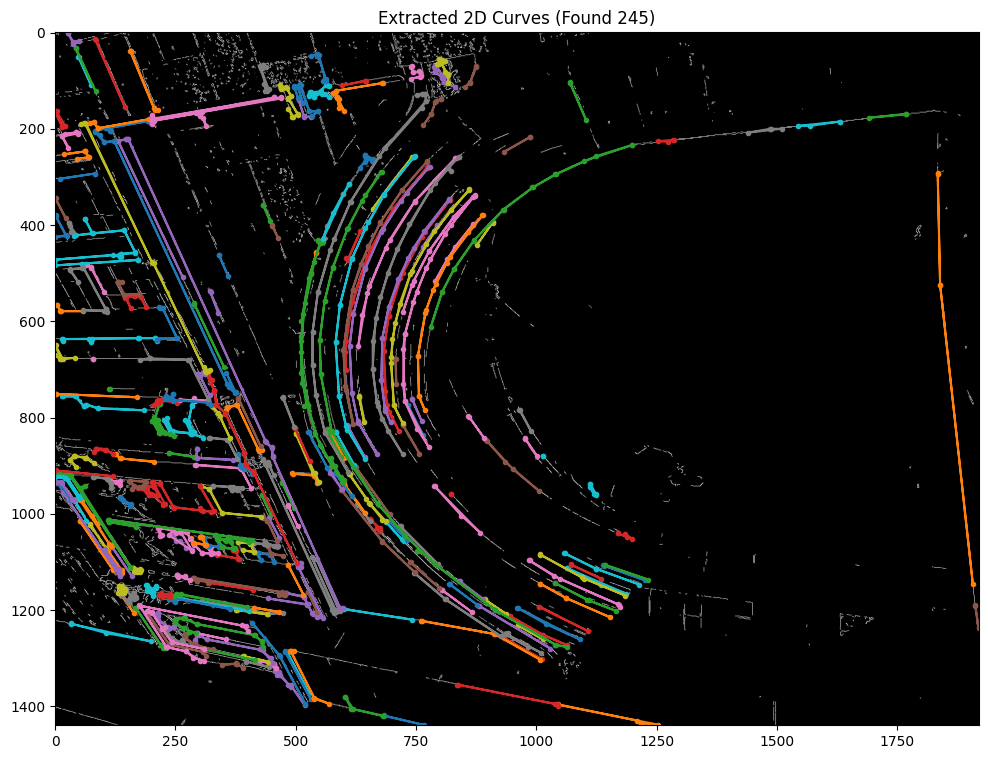

--- Debug plot closed. ---


In [13]:
output_dir = VIGNETTE_PATH / "results" / "feature_maps"
edge_map_file = str(output_dir / "edges.png")

extracted_2d_curves = extract_and_plot_2d_curves(
    edge_map_path=edge_map_file,
    simplification_tolerance=3.5, # Higher = simpler curves
    min_length_pixels=100,
    plot_curves=True
)

In [14]:
# project_and_visualize_3d_curves
import open3d as o3d

def project_and_visualize_3d_curves(
    vignette: 'ProcessedVignette',
    uv_curves_2d: List[List[Tuple[float, float]]],
    follow_surface: bool = True,
    show_context: bool = True,
    line_color: list = [1.0, 0.2, 0.2]
):
    """
    Step 2 of the workflow: Projects a given list of 2D UV curves into 3D
    and visualizes the result.

    Args:
        vignette: The processed vignette object.
        uv_curves_2d: The list of 2D UV curves to project.
        follow_surface: The projection mode (True for 'draping', False for 'snapping').
        show_context: If True, displays the base point cloud in gray.
        line_color: The color for the final 3D curves.
    """
    # --- Project the 2D curves into 3D ---
    curves_3d = project_curves_to_3d(
        vignette, 
        uv_curves_2d,
        follow_surface=follow_surface 
    )

    # --- Prepare geometries for visualization ---
    geometries_to_draw = []
    if show_context:
        context_pcd = vignette.to_open3d('rgb')
        context_pcd.paint_uniform_color([0.8, 0.8, 0.8])
        geometries_to_draw.append({"type": "points", "data": context_pcd})

    num_valid_curves = 0
    for curve_points in curves_3d:
        if curve_points is not None and len(curve_points) > 1:
            num_valid_curves += 1
            lineset = o3d.geometry.LineSet()
            lineset.points = o3d.utility.Vector3dVector(curve_points)
            lines = [[i, i + 1] for i in range(len(curve_points) - 1)]
            lineset.lines = o3d.utility.Vector2iVector(lines)
            
            geometries_to_draw.append({
                "type": "lines", "data": lineset, "color": line_color
            })

    # --- Visualize the final composition ---
    print(f"\n--- Visualizing {num_valid_curves} projected 3D curves ---")
    visualize_vignette(geometries_to_draw)

In [16]:
project_and_visualize_3d_curves(
    processed_vignette,
    uv_curves_2d=extracted_2d_curves,
    follow_surface=False,
    show_context=True,
    line_color=[0.2, 0.1, 0.7]
)


--- Projecting 245 curves (Mode: Nearest Neighbor) ---
[DEBUG] Projecting vignette to 2D and building KD-Tree...
Generating Open3D point cloud with 'rgb' colors...

--- Visualizing 245 projected 3D curves ---


#### Test Projecting Interaction ####

In [17]:
import numpy as np
from typing import List, Tuple, Dict

def create_parallel_lines_sketch() -> List[List[Tuple[float, float]]]:
    """Generates a series of parallel horizontal lines in UV space."""
    uv_curves = []
    for y_val in np.linspace(0.2, 0.8, 5): # 5 lines spaced vertically
        curve = [(0.1, y_val), (0.9, y_val)]
        uv_curves.append(curve)
    return uv_curves

def create_star_sketch() -> List[List[Tuple[float, float]]]:
    """Generates a 5-pointed star in UV space."""
    center_u, center_v = 0.5, 0.5
    outer_radius, inner_radius = 0.4, 0.15
    points = []
    for i in range(10):
        angle = np.pi / 2 + i * (2 * np.pi / 10)
        radius = outer_radius if i % 2 == 0 else inner_radius
        u = center_u + radius * np.cos(angle)
        v = center_v + radius * np.sin(angle)
        points.append((u, v))
    points.append(points[0]) # Close the loop
    return [points]

def create_tree_sketch() -> List[List[Tuple[float, float]]]:
    """Generates a branching, tree-like pattern using recursion."""
    all_segments = []
    
    def _generate_branch(start_point, angle, length, depth):
        if depth == 0:
            return
        
        # Calculate the end point of the current branch
        end_u = start_point[0] + length * np.cos(angle)
        end_v = start_point[1] + length * np.sin(angle)
        end_point = (end_u, end_v)
        
        # Add this segment as a new curve
        all_segments.append([start_point, end_point])
        
        # Recursively call for two new branches
        new_length = length * 0.75
        angle_split = np.deg2rad(30)
        _generate_branch(end_point, angle - angle_split, new_length, depth - 1)
        _generate_branch(end_point, angle + angle_split, new_length, depth - 1)

    # Start the trunk of the tree
    _generate_branch(start_point=(0.5, 0.1), angle=np.pi/2, length=0.25, depth=5)
    return all_segments

def create_sample_sketches() -> Dict[str, List[List[Tuple[float, float]]]]:
    """Generates and returns a dictionary of all sample sketches."""
    return {
        "Parallel Lines": create_parallel_lines_sketch(),
        "Star": create_star_sketch(),
        "Tree": create_tree_sketch()
    }

In [18]:
import matplotlib.pyplot as plt

def plot_2d_sketch(uv_curves: List[List[Tuple[float, float]]], title: str):
    """Visualizes a list of UV curves using Matplotlib."""
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.invert_yaxis() # Match image coordinate system (y=0 is at the top)
    
    for i, curve in enumerate(uv_curves):
        # Unzip the list of (u,v) tuples into two lists for plotting
        u_coords, v_coords = zip(*curve)
        ax.plot(u_coords, v_coords, '-o', markersize=4)
        
    plt.show()

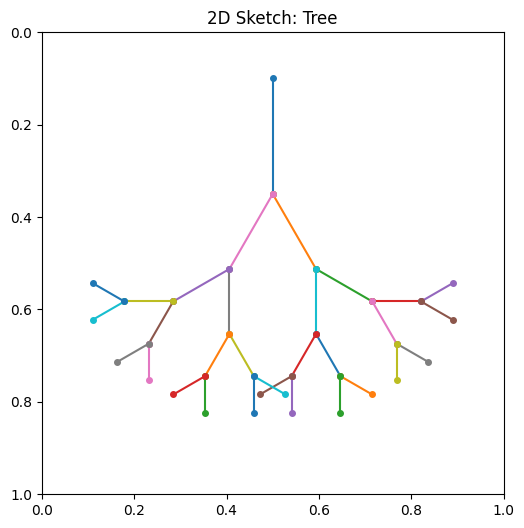

In [19]:
sketches = create_sample_sketches()
name = "Tree"
sketch = sketches[name]

plot_2d_sketch(sketch, title=f"2D Sketch: {name}")

In [20]:
project_and_visualize_3d_curves(
    processed_vignette,
    sketch,
    follow_surface=True,
    show_context=True
)


--- Projecting 31 curves (Mode: Surface Following) ---
[DEBUG] Depth map loaded with shape: (192, 256)
Generating Open3D point cloud with 'rgb' colors...

--- Visualizing 31 projected 3D curves ---


### Details ###

In [26]:
import open3d as o3d
import numpy as np

def visualize_detail_as_spheres(
    vignette: 'ProcessedVignette',
    power: float = 1.0,
    min_radius: float = 0.002,
    max_radius: float = 0.03,
    show_context: bool = True,
    color: list = [1.0, 0.8, 0.2]
):
    """
    Resamples a point cloud based on texture detail probability and visualizes
    the result as spheres whose radii are mapped to that detail value.

    Args:
        vignette: The processed vignette with the '2d_texture_detail' attribute.
        power: A contrast factor for the probability sampling. Values > 1.0
               make the sampling sparser and more focused on high-detail areas.
        min_radius: The radius of a sphere for the minimum detail value.
        max_radius: The radius of a sphere for the maximum detail value.
        show_context: If True, shows the original point cloud faintly in the background.
        color: The uniform color of the spheres.
    """
    print("✨ Visualizing texture detail as a field of sized spheres...")

    # --- 1. Get Detail Attribute and Create Probabilities ---
    detail_values = vignette.get_attribute('2d_texture_detail')
    if detail_values is None:
        raise ValueError("Attribute '2d_texture_detail' not found.")
        
    # Amplify the signal using the 'power' parameter to create probabilities
    keep_probabilities = np.power(detail_values, power)

    # --- 2. Probabilistically Resample the Point Cloud ---
    random_rolls = np.random.rand(vignette.n_points)
    keep_mask = keep_probabilities > random_rolls
    
    num_kept = np.sum(keep_mask)
    if num_kept == 0:
        print("[WARNING] No points were kept. Try decreasing the 'power' factor.")
        return

    # Filter to get only the points and detail values we're keeping
    kept_points = vignette.points[keep_mask]
    kept_detail_values = detail_values[keep_mask]
    print(f"   - Resampled to {num_kept} points based on detail probability.")

    # --- 3. Create Sized Spheres from the Kept Points ---
    min_val, max_val = kept_detail_values.min(), kept_detail_values.max()
    value_range = max_val - min_val if (max_val - min_val) > 1e-6 else 1.0

    merged_spheres = o3d.geometry.TriangleMesh()
    for i, pos in enumerate(kept_points):
        val = kept_detail_values[i]
        
        # Map the point's detail value to the desired radius scale
        normalized_val = (val - min_val) / value_range
        radius = min_radius + normalized_val * (max_radius - min_radius)

        glyph = o3d.geometry.TriangleMesh.create_sphere(radius=radius)
        glyph.translate(pos)
        merged_spheres += glyph
        
    # --- 4. Prepare and Render the Visualization ---
    geometries = []
    if show_context:
        context_pcd = vignette.to_open3d('rgb')
        context_pcd.paint_uniform_color([0.85, 0.85, 0.85])
        geometries.append({"type": "points", "data": context_pcd})
        
    geometries.append({
        "type": "mesh",
        "data": merged_spheres,
        "material": {"color": color}
    })
    
    visualize_vignette(geometries)
    print("Done.")

visualize_detail_as_spheres(
    processed_vignette,
    power=2.5, # Lower power = more points kept
    min_radius=0.002,
    max_radius=0.02,
    color=[0.2, 0.1, 0.7] 
)

✨ Visualizing texture detail as a field of sized spheres...
   - Resampled to 1621 points based on detail probability.
Generating Open3D point cloud with 'rgb' colors...
Done.


In [ ]:
import open3d as o3d
import numpy as np

def visualize_detail_as_spheres_or_web(
    vignette: 'ProcessedVignette',
    power: float = 1.0,
    show_edges: bool = False,
    # Sphere-specific parameters
    min_radius: float = 0.002,
    max_radius: float = 0.03,
    sphere_color: list = [1.0, 0.8, 0.2],
    # Edge-specific parameters
    num_neighbors_for_web: int = 5,
    line_color: list = [0.2, 0.2, 0.2],
    # General parameters
    show_context: bool = True
):
    """
    Visualizes texture detail by either creating sized spheres or a connecting web.

    Args:
        vignette: The processed vignette with the '2d_texture_detail' attribute.
        power: A contrast factor for the probability sampling.
        show_edges: If False (default), visualizes as sized spheres. If True,
                    visualizes as a connecting web of lines instead.
        min_radius: The minimum radius for spheres.
        max_radius: The maximum radius for spheres.
        sphere_color: The color of the spheres.
        num_neighbors_for_web: The number of neighbors to connect for the web.
        line_color: The color of the web lines.
        show_context: If True, shows the original point cloud faintly in the background.
    """
    if show_edges:
        print("🕸️  Visualizing texture detail as a connecting web...")
    else:
        print("✨ Visualizing texture detail as a field of sized spheres...")

    # --- 1. Resample the Point Cloud Based on Detail Probability ---
    detail_values = vignette.get_attribute('2d_texture_detail')
    if detail_values is None: raise ValueError("Attribute '2d_texture_detail' not found.")
        
    keep_probabilities = np.power(detail_values, power)
    random_rolls = np.random.rand(vignette.n_points)
    keep_mask = keep_probabilities > random_rolls
    
    num_kept = np.sum(keep_mask)
    if num_kept < 2:
        print("[WARNING] Not enough points were kept to create a visualization.")
        return

    kept_points = vignette.points[keep_mask]
    print(f"   - Resampled to {num_kept} points based on detail probability.")

    # --- 2. Prepare Visualization based on the 'show_edges' Flag ---
    geometries = []
    if show_context:
        context_pcd = vignette.to_open3d('rgb')
        context_pcd.paint_uniform_color([0.85, 0.85, 0.85])
        geometries.append({"type": "points", "data": context_pcd})

    if show_edges:
        # --- Generate and add the connecting web ---
        web_pcd_for_kdtree = o3d.geometry.PointCloud()
        web_pcd_for_kdtree.points = o3d.utility.Vector3dVector(kept_points)
        pcd_tree = o3d.geometry.KDTreeFlann(web_pcd_for_kdtree)
        lines = []
        for i in range(len(kept_points)):
            [k, idx, _] = pcd_tree.search_knn_vector_3d(kept_points[i], num_neighbors_for_web + 1)
            for neighbor_idx in idx[1:]:
                lines.append([i, neighbor_idx])
        
        web_lineset = o3d.geometry.LineSet()
        web_lineset.points = o3d.utility.Vector3dVector(kept_points)
        web_lineset.lines = o3d.utility.Vector2iVector(lines)
        web_lineset.paint_uniform_color(line_color)
        geometries.append({"type": "lines", "data": web_lineset})
    else:
        # --- Generate and add the sized spheres ---
        kept_detail_values = detail_values[keep_mask]
        min_val, max_val = kept_detail_values.min(), kept_detail_values.max()
        value_range = max_val - min_val if (max_val - min_val) > 1e-6 else 1.0

        merged_spheres = o3d.geometry.TriangleMesh()
        for i, pos in enumerate(kept_points):
            val = kept_detail_values[i]
            normalized_val = (val - min_val) / value_range
            radius = min_radius + normalized_val * (max_radius - min_radius)
            glyph = o3d.geometry.TriangleMesh.create_sphere(radius=radius)
            glyph.translate(pos)
            merged_spheres += glyph
        
        geometries.append({
            "type": "mesh",
            "data": merged_spheres,
            "material": {"color": sphere_color}
        })
    
    # --- 3. Render the Final Composition ---
    visualize_vignette(geometries)
    print("Done.")

visualize_detail_as_spheres_or_web(
    processed_vignette,
    power=3.0,
    show_edges=True,
    min_radius=0.01,
    max_radius=0.1,
    sphere_color=[0.2, 0.1, 0.7],
    num_neighbors_for_web=4,
    line_color=[0.2, 0.1, 0.7],
    show_context=False
)

🕸️  Visualizing texture detail as a connecting web...
   - Resampled to 1113 points based on detail probability.
Done.


### K Color ###

In [29]:
import open3d as o3d
import numpy as np

def visualize_stylized_colors(
    vignette: 'ProcessedVignette',
    color_index: int = None,
    show_context: bool = True
):
    """
    Visualizes the vignette using its stylized k-means colors, with added debug messages.
    """
    print("🎨 Visualizing stylized k-means colors...")

    # --- 1. Get the stylized color attribute ---
    stylized_colors = vignette.get_attribute('stylized_colors')
    if stylized_colors is None:
        raise ValueError("Attribute 'stylized_colors' not found. Please apply the stylized map first.")

    # --- Initial Debug Check ---
    print(f"\n[DEBUG] Initial 'stylized_colors' stats:")
    print(f"        - DType: {stylized_colors.dtype}")
    print(f"        - Shape: {stylized_colors.shape}")
    print(f"        - Min value: {np.min(stylized_colors)}")
    print(f"        - Max value: {np.max(stylized_colors)}")
    print(f"        - Mean value: {np.mean(stylized_colors)}\n")

    # --- Normalization Check ---
    if np.max(stylized_colors) > 1.0:
        print("[DEBUG] Max value is > 1.0. Normalizing from 0-255 range to 0-1 range.")
        stylized_colors = stylized_colors.astype(np.float64) / 255.0
        print(f"        - Post-normalization Max value: {np.max(stylized_colors)}\n")
    else:
        print("[DEBUG] Max value is <= 1.0. No normalization needed.\n")

    geometries_to_draw = []

    if color_index is not None:
        # --- Isolate Color Logic Debug ---
        unique_colors = np.unique(np.round(stylized_colors * 255), axis=0) / 255.0
        
        if color_index >= len(unique_colors):
            print(f"[ERROR] Invalid color_index: {color_index}. Vignette only has {len(unique_colors)} stylized colors.")
            return
            
        target_color = unique_colors[color_index]
        print(f"[DEBUG] Isolating color index {color_index}.")
        print(f"        - Target color (0-1 range): {np.round(target_color, 3)}")

        mask = np.all(np.isclose(stylized_colors, target_color, atol=1/255), axis=1)
        print(f"        - Found {np.sum(mask)} points matching the target color.")

        if np.sum(mask) == 0:
            print("[WARNING] No points matched the target color. This might be a floating point precision issue.")

        selected_pcd = o3d.geometry.PointCloud()
        selected_pcd.points = o3d.utility.Vector3dVector(vignette.points[mask])
        selected_pcd.colors = o3d.utility.Vector3dVector(stylized_colors[mask])
        
        if show_context:
            context_pcd = o3d.geometry.PointCloud()
            context_pcd.points = o3d.utility.Vector3dVector(vignette.points[~mask])
            context_pcd.paint_uniform_color([0.85, 0.85, 0.85])
            geometries_to_draw.append({"type": "points", "data": context_pcd})
        
        geometries_to_draw.append({"type": "points", "data": selected_pcd})

    else:
        # --- Full Visualization Logic ---
        print("[DEBUG] Preparing to visualize all stylized colors.")
        full_stylized_pcd = o3d.geometry.PointCloud()
        full_stylized_pcd.points = o3d.utility.Vector3dVector(vignette.points)
        full_stylized_pcd.colors = o3d.utility.Vector3dVector(stylized_colors)
        geometries_to_draw.append({"type": "points", "data": full_stylized_pcd})

    visualize_vignette(geometries_to_draw)
    print("Done.")


# --- Example Usage ---
# Assuming 'processed_vignette' has the 'stylized_colors' attribute.

# **Idea 1: See the full k-means result**
# This shows the entire object with its simplified, posterized colors.
visualize_stylized_colors(processed_vignette, color_index=1, show_context=True)

🎨 Visualizing stylized k-means colors...

[DEBUG] Initial 'stylized_colors' stats:
        - DType: float64
        - Shape: (3597, 3)
        - Min value: 0.0
        - Max value: 0.5607843137254902
        - Mean value: 0.24815741512989217

[DEBUG] Max value is <= 1.0. No normalization needed.

[DEBUG] Isolating color index 1.
        - Target color (0-1 range): [0.161 0.133 0.11 ]
        - Found 1869 points matching the target color.
Done.


In [13]:
import open3d as o3d
import numpy as np

def visualize_color_segment_web(
    vignette: 'ProcessedVignette',
    color_index: int,
    show_context: bool = True,
    show_full_segment: bool = True, # NEW FLAG
    add_connections: bool = True,
    density: float = 0.3,
    num_neighbors_for_web: int = 5,
    point_color: list = None,
    line_color: list = [0.2, 0.2, 0.2],
    show_web_vertices_as_spheres: bool = False,
    sphere_radius: float = 0.01,
    sphere_color: list = None
):
    """
    Isolates a color segment and optionally overlays a sparse web, with full
    artistic control over the visibility of each component.

    Args:
        vignette: The processed vignette.
        color_index: The index of the color palette to isolate.
        show_context: If True, shows the other points in gray.
        show_full_segment: If True, displays the complete point cloud of the selected color.
        add_connections: If True, generates the web overlay.
        density: The fraction of points to use for the web's vertices.
        num_neighbors_for_web: The number of neighbors to connect in the web.
        point_color: (Optional) Overrides the selected points' k-means color.
        line_color: The color for the connection web.
        show_web_vertices_as_spheres: If True, draws spheres at the web's vertices.
        sphere_radius: The radius of the vertex spheres.
        sphere_color: (Optional) The color of the vertex spheres. Defaults to yellow.
    """
    print(f"🕸️  Visualizing color segment {color_index}...")

    # --- 1. Get and Normalize Colors ---
    stylized_colors = vignette.get_attribute('stylized_colors')
    if stylized_colors is None: raise ValueError("Attribute 'stylized_colors' not found.")
    if np.max(stylized_colors) > 1.0:
        stylized_colors = stylized_colors.astype(np.float64) / 255.0

    # --- 2. Isolate the Target Color Segment ---
    unique_colors = np.unique(np.round(stylized_colors * 255), axis=0) / 255.0
    if color_index >= len(unique_colors):
        print(f"[ERROR] Invalid color_index: {color_index}.")
        return
    target_color = unique_colors[color_index]
    
    segment_mask = np.all(np.isclose(stylized_colors, target_color, atol=1/255), axis=1)
    segment_points = vignette.points[segment_mask]
    segment_colors = stylized_colors[segment_mask]

    if len(segment_points) < 2:
        print("[WARNING] The selected color segment has too few points to process.")
        return

    geometries_to_draw = []

    # --- 3. (Optional) Add Context Points ---
    if show_context:
        context_pcd = o3d.geometry.PointCloud()
        context_pcd.points = o3d.utility.Vector3dVector(vignette.points[~segment_mask])
        context_pcd.paint_uniform_color([0.85, 0.85, 0.85])
        geometries_to_draw.append({"type": "points", "data": context_pcd})

    # --- 4. (Optional) Create and Add the FULL Selected Point Cloud ---
    if show_full_segment:
        full_segment_pcd = o3d.geometry.PointCloud()
        full_segment_pcd.points = o3d.utility.Vector3dVector(segment_points)
        if point_color is not None:
            full_segment_pcd.paint_uniform_color(point_color)
        else:
            full_segment_pcd.colors = o3d.utility.Vector3dVector(segment_colors)
        geometries_to_draw.append({"type": "points", "data": full_segment_pcd})

    # --- 5. (Optional) Generate and Add Web and Sphere Overlays ---
    if add_connections:
        num_points_to_sample = int(len(segment_points) * density)
        if num_points_to_sample > 1:
            sampled_indices = np.random.choice(len(segment_points), num_points_to_sample, replace=False)
            web_points = segment_points[sampled_indices]
            
            # Add Web Lines
            web_pcd_for_kdtree = o3d.geometry.PointCloud(); web_pcd_for_kdtree.points = o3d.utility.Vector3dVector(web_points)
            pcd_tree = o3d.geometry.KDTreeFlann(web_pcd_for_kdtree)
            lines = []
            for i in range(len(web_points)):
                [k, idx, _] = pcd_tree.search_knn_vector_3d(web_points[i], num_neighbors_for_web + 1)
                for neighbor_idx in idx[1:]: lines.append([i, neighbor_idx])
            
            web_lineset = o3d.geometry.LineSet(); web_lineset.points = o3d.utility.Vector3dVector(web_points); web_lineset.lines = o3d.utility.Vector2iVector(lines); web_lineset.paint_uniform_color(line_color)
            geometries_to_draw.append({"type": "lines", "data": web_lineset})

            # Add Vertex Spheres
            if show_web_vertices_as_spheres:
                merged_spheres = o3d.geometry.TriangleMesh()
                for pos in web_points:
                    glyph = o3d.geometry.TriangleMesh.create_sphere(radius=sphere_radius)
                    glyph.translate(pos)
                    merged_spheres += glyph
                
                final_sphere_color = sphere_color if sphere_color is not None else [1.0, 0.8, 0.0]
                geometries_to_draw.append({
                    "type": "mesh", "data": merged_spheres, "material": {"color": final_sphere_color}
                })

    # --- 6. Visualize the final composition ---
    visualize_vignette(geometries_to_draw)
    print("Done.")

# --- Example Usage ---
visualize_color_segment_web(
    processed_vignette, 
    color_index=1, 
    show_context=True,
    show_full_segment=False,
    add_connections=True,
    density=0.25,
    num_neighbors_for_web=4,
    point_color=[0.8, 0.8, 0.8],
    line_color=[0.2, 0.2, 0.2],
    show_web_vertices_as_spheres=True,
    sphere_radius=0.002,
    sphere_color=[0.2, 0.2, 0.2]   
)

🕸️  Visualizing color segment 1...
Done.


In [27]:
import open3d as o3d
import numpy as np

def visualize_color_segment_as_pivoting_mesh(
    vignette: 'ProcessedVignette',
    color_index: int,
    ball_radii: list = [0.01, 0.02, 0.04],
    show_context: bool = True
):
    """
    Isolates a color segment and visualizes it as a mesh using the
    Ball Pivoting algorithm for better surface reconstruction.

    Args:
        vignette: The processed vignette with the 'stylized_colors' attribute.
        color_index: The index of the color palette to isolate and mesh.
        ball_radii: A list of radii for the virtual ball. The algorithm tries
                    smaller radii first to capture detail, then larger ones to
                    fill holes.
        show_context: If True, shows the other points in gray.
    """
    print(f"MESH Visualizing color segment {color_index} with Ball Pivoting...")

    # --- 1. Get and Isolate the Target Color Segment ---
    stylized_colors = vignette.get_attribute('stylized_colors')
    if stylized_colors is None: raise ValueError("Attribute 'stylized_colors' not found.")
    if np.max(stylized_colors) > 1.0:
        stylized_colors = stylized_colors.astype(np.float64) / 255.0
    
    unique_colors = np.unique(np.round(stylized_colors * 255), axis=0) / 255.0
    if color_index >= len(unique_colors):
        print(f"[ERROR] Invalid color_index: {color_index}.")
        return
    target_color = unique_colors[color_index]
    
    segment_mask = np.all(np.isclose(stylized_colors, target_color, atol=1/255), axis=1)
    segment_points = vignette.points[segment_mask]

    if len(segment_points) < 20:
        print("[WARNING] The selected color segment has too few points for robust meshing.")
        return

    geometries_to_draw = []

    # --- 2. (Optional) Add Context Points ---
    if show_context:
        context_pcd = o3d.geometry.PointCloud()
        context_pcd.points = o3d.utility.Vector3dVector(vignette.points[~segment_mask])
        context_pcd.paint_uniform_color([0.85, 0.85, 0.85])
        geometries_to_draw.append({"type": "points", "data": context_pcd})

    # --- 3. Generate the Ball Pivoting Mesh ---
    print(f"   - Generating mesh with ball radii: {ball_radii}...")
    pcd_for_meshing = o3d.geometry.PointCloud()
    pcd_for_meshing.points = o3d.utility.Vector3dVector(segment_points)
    
    # The point cloud MUST have normals for this algorithm to work.
    pcd_for_meshing.estimate_normals()
    pcd_for_meshing.orient_normals_consistent_tangent_plane(15)
    
    # The Ball Pivoting algorithm creates the mesh
    radii_vector = o3d.utility.DoubleVector(ball_radii)
    mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
        pcd_for_meshing, radii_vector
    )
    
    # Clean up the mesh for a better result
    mesh.remove_degenerate_triangles()
    mesh.compute_vertex_normals() # Re-compute normals for final consistency

    print(f"   - Generated mesh with {len(mesh.triangles)} triangles.")
    
    geometries_to_draw.append({
        "type": "mesh",
        "data": mesh,
        "material": {"color": target_color.tolist()}
    })

    # --- 4. Visualize the final composition ---
    visualize_vignette(geometries_to_draw)
    print("Done.")

visualize_color_segment_as_pivoting_mesh(
    processed_vignette, 
    color_index=1, 
    ball_radii=[0.015],
    show_context=True
)

MESH Visualizing color segment 1 with Ball Pivoting...
   - Generating mesh with ball radii: [0.015]...
   - Generated mesh with 0 triangles.
[Open3D WARNING] [SimpleShaderForTriangleMesh] Binding failed with empty triangle mesh.
[Open3D WARNING] [SimpleShaderForTriangleMesh] Binding failed when preparing data.
[Open3D WARNING] [SimpleShaderForTriangleMesh] Something is wrong in compiling or binding.
[Open3D WARNING] [SimpleShaderForTriangleMesh] Binding failed with empty triangle mesh.
[Open3D WARNING] [SimpleShaderForTriangleMesh] Binding failed when preparing data.
[Open3D WARNING] [SimpleShaderForTriangleMesh] Something is wrong in compiling or binding.
[Open3D WARNING] [SimpleShaderForTriangleMesh] Binding failed with empty triangle mesh.
[Open3D WARNING] [SimpleShaderForTriangleMesh] Binding failed when preparing data.
[Open3D WARNING] [SimpleShaderForTriangleMesh] Something is wrong in compiling or binding.
[Open3D WARNING] [SimpleShaderForTriangleMesh] Binding failed with empty

## Global Abstractions ##

### Main Axes ###

In [22]:
# Visualize Axes

import open3d as o3d
import numpy as np
from typing import Literal

def visualize_structural_axes(
    vignette: 'ProcessedVignette',
    mode: Literal['axes', 'obb', 'planes'] = 'axes',
    show_context: bool = True,
    scale_multiplier: float = 2.0
):
    """
    Visualizes the dominant axes from PCA in several creative ways.
    (UPDATED with full axes and double-sided planes)

    Args:
        vignette: The processed vignette with 'structural_properties' calculated.
        mode: The visualization style:
              - 'axes': Draws the 3 principal axes as full lines.
              - 'obb': Draws the oriented bounding box.
              - 'planes': Draws the 3 double-sided principal planes.
        show_context: If True, displays the base point cloud in gray.
        scale_multiplier: Adjusts the size of the drawn axes or planes.
    """
    print(f"🧭 Visualizing structural properties in '{mode}' mode...")
    
    all_props = vignette.get_abstractions('structural_properties')
    if not all_props:
        print("[ERROR] 'structural_properties' not found. Please run analysis first.")
        return

    geometries_to_draw = []
    if show_context:
        context_pcd = vignette.to_open3d('rgb')
        context_pcd.paint_uniform_color([0.8, 0.8, 0.8])
        geometries_to_draw.append({"type": "points", "data": context_pcd})

    colors = [[1, 0, 0], [0, 1, 0], [0, 0, 1]] # X, Y, Z in Red, Green, Blue

    for i, props in enumerate(all_props):
        centroid = np.array(props['centroid'])
        axes = np.array(props['axes'])
        extents = np.sqrt(props['variances']) * scale_multiplier

        if mode == 'axes':
            # [EDIT 1] Create full axis lines passing through the centroid.
            points = []
            lines = []
            for i in range(3):
                axis_vec = axes[i]
                start_point = centroid - axis_vec * extents[i]
                end_point = centroid + axis_vec * extents[i]
                
                # Each line is now a pair of points: start and end
                points.extend([start_point, end_point])
                lines.append([i * 2, i * 2 + 1])

            lineset = o3d.geometry.LineSet(
                points=o3d.utility.Vector3dVector(points),
                lines=o3d.utility.Vector2iVector(lines)
            )
            # Assign a color to each of the 3 lines
            lineset.colors = o3d.utility.Vector3dVector(colors)
            geometries_to_draw.append({"type": "lines", "data": lineset})

        elif mode == 'obb':
            obb = o3d.geometry.OrientedBoundingBox(center=centroid, R=axes.T, extent=extents*2)
            obb.color = colors[i % len(colors)]
            geometries_to_draw.append({"type": "lines", "data": obb})

        elif mode == 'planes':
            for i in range(3):
                p1 = centroid + axes[(i+1)%3] * extents[(i+1)%3] + axes[(i+2)%3] * extents[(i+2)%3]
                p2 = centroid + axes[(i+1)%3] * extents[(i+1)%3] - axes[(i+2)%3] * extents[(i+2)%3]
                p3 = centroid - axes[(i+1)%3] * extents[(i+1)%3] - axes[(i+2)%3] * extents[(i+2)%3]
                p4 = centroid - axes[(i+1)%3] * extents[(i+1)%3] + axes[(i+2)%3] * extents[(i+2)%3]
                
                plane_mesh = o3d.geometry.TriangleMesh()
                plane_mesh.vertices = o3d.utility.Vector3dVector([p1, p2, p3, p4])
                
                # [EDIT 2] Add triangles for both front and back faces.
                front_triangles = [[0, 1, 2], [0, 2, 3]]
                back_triangles = [[0, 2, 1], [0, 3, 2]] # Same vertices, opposite order
                plane_mesh.triangles = o3d.utility.Vector3iVector(front_triangles + back_triangles)
                
                geometries_to_draw.append({
                    "type": "mesh", 
                    "data": plane_mesh, 
                    "material": {"color": colors[i], "transparency": 0.7}
                })
    
    visualize_vignette(geometries_to_draw)

In [25]:
visualize_structural_axes(
    processed_vignette, 
    mode='obb' # 'axes', 'obb', 'planes'
)

🧭 Visualizing structural properties in 'obb' mode...
Generating Open3D point cloud with 'rgb' colors...


### Symmetry ###

In [26]:
import open3d as o3d
import numpy as np
from typing import Literal, List

def visualize_symmetry(
    vignette: 'ProcessedVignette',
    show_plane: bool = True,
    show_painted_sides: bool = False,
    use_symmetrize: bool = False,
    plane_size: float = 0.5,
    side_to_keep: Literal['positive', 'negative'] = 'positive',
    positive_side_color: List[float] = [1.0, 0.3, 0.3], # NEW: Custom color for positive side
    negative_side_color: List[float] = [0.3, 0.3, 1.0]  # NEW: Custom color for negative side
):
    """
    Visualizes the first detected symmetry plane with modular components.
    (UPDATED with plane fix and custom paint colors)

    Args:
        vignette: The vignette with 'symmetries' calculated.
        show_plane: If True, draws a wireframe of the symmetry plane.
        show_painted_sides: If True, colors points on opposite sides of the plane.
        use_symmetrize: If True, generates a perfectly symmetrical object.
        plane_size: Controls the size of the wireframe plane.
        side_to_keep: In 'symmetrize' mode, which side to use for reflection.
        positive_side_color: The color for points on the side the normal points towards.
        negative_side_color: The color for points on the other side.
    """
    print("🎨 Visualizing symmetry...")
    
    symmetries = vignette.get_abstractions('symmetries')
    if not symmetries:
        print("[INFO] No symmetries found to visualize.")
        return
    symmetry_data = symmetries[0]
    
    p0 = np.array(symmetry_data['plane_point'])
    n = np.array(symmetry_data['plane_normal'])
    n /= np.linalg.norm(n)

    geometries_to_draw = []
    
    vectors_from_plane = vignette.points - p0
    dot_products = np.dot(vectors_from_plane, n)
    
    if use_symmetrize:
        # ... (symmetrize logic is unchanged)
        print("   - Generating symmetrized model...")
        source_mask = dot_products > 0 if side_to_keep == 'positive' else dot_products <= 0
        source_points = vignette.points[source_mask]
        vectors_from_plane_source = source_points - p0
        dots = np.dot(vectors_from_plane_source, n)
        reflected_points = source_points - 2 * dots[:, np.newaxis] * n
        source_pcd = o3d.geometry.PointCloud(); source_pcd.points = o3d.utility.Vector3dVector(source_points)
        source_pcd.paint_uniform_color(positive_side_color)
        reflected_pcd = o3d.geometry.PointCloud(); reflected_pcd.points = o3d.utility.Vector3dVector(reflected_points)
        reflected_pcd.paint_uniform_color(negative_side_color)
        geometries_to_draw.extend([{"type": "points", "data": source_pcd}, {"type": "points", "data": reflected_pcd}])
        visualize_vignette(geometries_to_draw)
        return

    # --- Standard visualization modes ---
    if show_painted_sides:
        print("   - Painting points by side...")
        colors = np.zeros_like(vignette.points)
        # [NEW] Use the parameters for coloring
        colors[dot_products > 0] = positive_side_color
        colors[dot_products <= 0] = negative_side_color
        
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(vignette.points)
        pcd.colors = o3d.utility.Vector3dVector(colors)
        geometries_to_draw.append({"type": "points", "data": pcd})
    else:
        geometries_to_draw.append({"type": "points", "data": vignette.to_open3d('rgb')})

    if show_plane:
        print("   - Drawing symmetry plane wireframe...")
        u = np.cross(n, [0, 0, 1]) if np.abs(n[2]) < 0.9 else np.cross(n, [1, 0, 0])
        u /= np.linalg.norm(u)
        v = np.cross(n, u)
        
        # [FIX] Explicitly define the 4 corners in order
        c1 = p0 + u * plane_size + v * plane_size
        c2 = p0 - u * plane_size + v * plane_size
        c3 = p0 - u * plane_size - v * plane_size
        c4 = p0 + u * plane_size - v * plane_size
        
        plane_lines = o3d.geometry.LineSet()
        plane_lines.points = o3d.utility.Vector3dVector([c1, c2, c3, c4])
        # Define the lines to connect the corners in a square loop
        plane_lines.lines = o3d.utility.Vector2iVector([[0, 1], [1, 2], [2, 3], [3, 0]])
        
        geometries_to_draw.append({"type": "lines", "data": plane_lines, "color": [1.0, 0.8, 0.0]})

    visualize_vignette(geometries_to_draw)

In [28]:
visualize_symmetry(
    processed_vignette,
    show_plane=True,
    show_painted_sides=True,
    plane_size=0.3,
    use_symmetrize=False,
    positive_side_color=[0.8, 0.2, 0.2],
    negative_side_color=[0.2, 0.2, 0.8]
)

🎨 Visualizing symmetry...
   - Painting points by side...
   - Drawing symmetry plane wireframe...


### Primitives ###

In [28]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
from typing import Literal, Dict, Any

def _create_primitive_geometry(props: Dict[str, Any], primitive_type: str) -> o3d.geometry.TriangleMesh:
    """
    Helper to create a mesh for a primitive using its OBB.
    (UPDATED with correct centering logic for proper alignment)
    """
    center = np.array(props['obb_center'])
    R = np.array(props['obb_rotation'])
    extent = np.array(props['obb_extent'])
    
    mesh = None
    if primitive_type in ['plane', 'cuboid']:
        mesh = o3d.geometry.TriangleMesh.create_box(width=extent[0], height=extent[1], depth=extent[2])
        # [THE FIX] Center the box at the origin before rotating and translating.
        mesh.translate(-extent / 2)
        
    elif primitive_type == 'cylinder':
        height = np.max(extent)
        radius = np.mean(np.sort(extent)[:2]) / 2.0
        mesh = o3d.geometry.TriangleMesh.create_cylinder(radius=radius, height=height)
        # [THE FIX] Center the cylinder at the origin.
        mesh.translate([0, 0, -height / 2])

    elif primitive_type == 'sphere':
        # Spheres are already created at the origin, so they don't need this fix.
        radius = np.mean(extent) / 2.0
        mesh = o3d.geometry.TriangleMesh.create_sphere(radius=radius)
    
    if mesh:
        # 2. Rotate the centered primitive to the correct orientation.
        mesh.rotate(R, center=[0, 0, 0])
        # 3. Translate the correctly oriented primitive to its final position.
        mesh.translate(center)
        return mesh
        
    return None


def visualize_fitted_primitives(
    vignette: 'ProcessedVignette',
    primitive_type: str,
    mode: Literal['ghost_and_armature', 'blueprint', 'exploded_view'] = 'ghost_and_armature',
    show_as_wireframe: bool = False, # NEW FLAG for exploded view
    explode_factor: float = 1.5
):
    """
    Visualizes fitted primitives in one of several modes. 'exploded_view' can
    now render primitives as solid meshes or wireframes.

    Args:
        vignette: The processed vignette with primitives calculated.
        primitive_type: The plural name of the primitive type to visualize.
        mode: The visualization style.
        show_as_wireframe: [Used in 'exploded_view' mode only] If True, renders
                           the exploded parts as wireframes instead of solid meshes.
        explode_factor: Controls the separation distance in 'exploded_view' mode.
    """
    print(f"🎨 Visualizing fitted '{primitive_type}' in '{mode}' mode...")

    all_primitives = vignette.get_abstractions(primitive_type)
    if not all_primitives:
        print(f"[ERROR] No abstractions of type '{primitive_type}' found.")
        return

    geometries = []
    colors = plt.get_cmap('viridis')(np.linspace(0, 1, len(all_primitives)))[:, :3]

    if mode == 'ghost_and_armature':
        context_pcd = vignette.to_open3d('rgb')
        context_pcd.paint_uniform_color([0.8, 0.8, 0.8])
        geometries.append({"type": "points", "data": context_pcd})
        for i, props in enumerate(all_primitives):
            mesh = _create_primitive_geometry(props, primitive_type.rstrip('s'))
            if mesh:
                geometries.append({"type": "mesh", "data": mesh, "material": {"color": colors[i]}})

    elif mode == 'blueprint':
        geometries.append({"type": "points", "data": vignette.to_open3d('rgb'), "color": [0.9, 0.9, 0.9]})
        for i, props in enumerate(all_primitives):
            obb = o3d.geometry.OrientedBoundingBox(
                center=props['obb_center'], R=props['obb_rotation'], extent=props['obb_extent']
            )
            geometries.append({"type": "lines", "data": obb, "color": colors[i]})

    elif mode == 'exploded_view':
        global_centroid = vignette.points.mean(axis=0)
        for i, props in enumerate(all_primitives):
            primitive_centroid = np.array(props['obb_center'])
            direction = (primitive_centroid - global_centroid) * explode_factor

            # --- [NEW] Conditional Geometry Creation ---
            if show_as_wireframe:
                # Create and translate the wireframe (OBB)
                obb = o3d.geometry.OrientedBoundingBox(
                    center=props['obb_center'], R=props['obb_rotation'], extent=props['obb_extent']
                )
                obb.translate(direction)
                geometries.append({"type": "lines", "data": obb, "color": colors[i]})
            else:
                # Create and translate the solid mesh
                mesh = _create_primitive_geometry(props, primitive_type.rstrip('s'))
                if not mesh: continue
                mesh.translate(direction)
                geometries.append({"type": "mesh", "data": mesh, "material": {"color": colors[i]}})
            
            # Always translate the corresponding inlier points
            inlier_points = vignette.points[props['point_indices']]
            inlier_colors = vignette.colors[props['point_indices']]
            inlier_pcd = o3d.geometry.PointCloud()
            inlier_pcd.points = o3d.utility.Vector3dVector(inlier_points + direction)
            inlier_pcd.colors = o3d.utility.Vector3dVector(inlier_colors)
            geometries.append({"type": "points", "data": inlier_pcd})

    visualize_vignette(geometries)

In [ ]:
visualize_fitted_primitives(
    processed_vignette,
    primitive_type='planes',
    mode='exploded_view', # 'ghost_and_armature', 'blueprint', 'exploded_view'
    explode_factor=0,
    show_as_wireframe=True
)

🎨 Visualizing fitted 'planes' in 'exploded_view' mode...


In [29]:
visualize_fitted_primitives(
    processed_vignette,
    primitive_type='planes',
    mode='blueprint', # 'ghost_and_armature', 'blueprint', 'exploded_view'
    explode_factor=2,
    show_as_wireframe=True
)

🎨 Visualizing fitted 'planes' in 'blueprint' mode...
Generating Open3D point cloud with 'rgb' colors...


### Primitive Relations ###

In [10]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Any

def visualize_primitive_relations(
    vignette: 'ProcessedVignette',
    show_context: bool = True
):
    """
    Visualizes inter-primitive relationships stored in the vignette.
    - For 'perpendicular' planes, it draws their wireframes and intersection line.
    - For 'parallel' planes, it draws their wireframes and a connecting line.
    """
    print("📐 Visualizing primitive relationships...")

    # 1. Fetch all primitive and relation data
    all_relations = vignette.get_abstractions('primitive_relations')
    all_planes = vignette.get_abstractions('planes')

    if not all_relations or not all_planes:
        print("[INFO] No primitive relations or planes found to visualize.")
        return

    # Create a lookup dictionary for quick access to plane data by ID
    planes_by_id = {f"plane_{p['plane_id']}": p for p in all_planes}

    geometries_to_draw = []
    if show_context:
        context_pcd = vignette.to_open3d('rgb')
        context_pcd.paint_uniform_color([0.85, 0.85, 0.85])
        geometries_to_draw.append({"type": "points", "data": context_pcd})

    # 2. Iterate through each stored relationship
    for i, relation in enumerate(all_relations):
        primitive_ids = relation['primitives']
        
        # Ensure both primitives in the relation are planes we have data for
        if not all(p_id in planes_by_id for p_id in primitive_ids):
            continue

        plane1_props = planes_by_id[primitive_ids[0]]
        plane2_props = planes_by_id[primitive_ids[1]]
        
        # Draw the wireframes of the two planes involved
        obb1 = o3d.geometry.OrientedBoundingBox(center=plane1_props['obb_center'], R=plane1_props['obb_rotation'], extent=plane1_props['obb_extent'])
        obb2 = o3d.geometry.OrientedBoundingBox(center=plane2_props['obb_center'], R=plane2_props['obb_rotation'], extent=plane2_props['obb_extent'])
        geometries_to_draw.append({"type": "lines", "data": obb1, "color": [0.5, 0.5, 0.5]})
        geometries_to_draw.append({"type": "lines", "data": obb2, "color": [0.5, 0.5, 0.5]})

        if relation['type'] == 'perpendicular':
            # --- Calculate and draw the intersection line ---
            eq1 = np.array(plane1_props['equation'])
            eq2 = np.array(plane2_props['equation'])
            n1, n2 = eq1[:3], eq2[:3]
            
            # The direction of the intersection line is the cross product of the normals
            line_dir = np.cross(n1, n2)
            line_dir /= np.linalg.norm(line_dir)
            
            # To find a point on the line, we solve the system of 2 plane equations.
            # We can set one coordinate to 0 (e.g., z=0) and solve for x and y.
            # This is a robust way to handle all cases.
            A = np.array([n1[:2], n2[:2]])
            d = np.array([-eq1[3], -eq2[3]])
            try:
                # Solve for x, y with z=0
                xy = np.linalg.solve(A, d)
                point_on_line = np.array([xy[0], xy[1], 0.0])
            except np.linalg.LinAlgError:
                # If that fails (line is parallel to XY plane), try with y=0
                A = np.array([[n1[0], n1[2]], [n2[0], n2[2]]])
                d = np.array([-eq1[3], -eq2[3]])
                xz = np.linalg.solve(A, d)
                point_on_line = np.array([xz[0], 0.0, xz[1]])

            # Draw a segment of the infinite line for visualization
            line_length = np.mean(plane1_props['obb_extent']) # Use OBB size as a scale
            p_start = point_on_line - line_dir * line_length
            p_end = point_on_line + line_dir * line_length
            
            intersection_line = o3d.geometry.LineSet()
            intersection_line.points = o3d.utility.Vector3dVector([p_start, p_end])
            intersection_line.lines = o3d.utility.Vector2iVector([[0, 1]])
            geometries_to_draw.append({"type": "lines", "data": intersection_line, "color": [1.0, 0.2, 0.2]})

        elif relation['type'] == 'parallel':
            # --- Draw a line connecting the centers of the parallel planes ---
            c1 = np.array(plane1_props['obb_center'])
            c2 = np.array(plane2_props['obb_center'])
            
            connector_line = o3d.geometry.LineSet()
            connector_line.points = o3d.utility.Vector3dVector([c1, c2])
            connector_line.lines = o3d.utility.Vector2iVector([[0, 1]])
            geometries_to_draw.append({"type": "lines", "data": connector_line, "color": [0.2, 1.0, 0.2]})
            
    # 3. Visualize the final composition
    visualize_vignette(geometries_to_draw)
    '''
    visualize_vignette_orbiting(
        geometries_to_draw,
        output_gif_path= out_path / "orbit.gif",
        distance=1.8,         # How far the camera is from the center
        height=1.0,           # How high the camera is
        duration_seconds=4    # How long one full circle takes
    )
    '''

In [11]:
visualize_primitive_relations(processed_vignette)

📐 Visualizing primitive relationships...
Generating Open3D point cloud with 'rgb' colors...
